# Model Replication

In [51]:
# imports
import pandas as pd
import numpy as np
import re
import pprint
import statsmodels.api as sm
from patsy import dmatrix, dmatrices, build_design_matrices
from scipy.linalg import qr, svd, solve_triangular
from statsmodels.stats import multitest
from statsmodels.regression.mixed_linear_model import MixedLM
from sklearn.compose import ColumnTransformer
from typing import Dict, Any, List, Optional
import time
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from statsmodels.regression.mixed_linear_model import MixedLM
from scipy import stats
from scipy.stats import levene, norm
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib
import seaborn as sns
from matplotlib.colors import to_rgb
import colorsys
import itertools

plt.rcParams['figure.dpi'] = 900
colors = plt.colormaps["Dark2"].colors
# set Arial as default font
plt.rcParams['font.family'] = 'Arial'
from tqdm import tqdm

# silence warnings because the NN has a lot of them
import warnings
warnings.filterwarnings("ignore")
import random

# for saving model params
import pickle

# for feature importance
import shap
from sklearn.metrics import mean_squared_error
import copy
import ast

In [2]:
### OBSERVATIONAL-LEVEL DATA
df_observation_level_data = pd.read_csv("../outputs/observation_level_dv_with_composition.csv").drop(columns=["features", "synergy"])

In [3]:
# we need to merge this with information about the (1) task block order; (2) task order within the block; (3) stage order within the task

# this requires us to get info about the tasks and stages
df_rounds = pd.read_csv("../outputs/rounds.csv")

In [4]:
def add_task_ordering_column(df):
    # Get ordering per gameId
    orderings = (
        df.sort_values(['gameId', 'data.anonName'])
          .groupby('gameId')['data.type']
          .apply(list)
          .reset_index(name='ordering')
    )
    
    # Convert list to tuple for immutability
    orderings['ordering'] = orderings['ordering'].apply(tuple)
    
    # Merge back into the original dataframe
    df_with_ordering = df.merge(orderings, on='gameId', how='left')
    
    return df_with_ordering

df_rounds = add_task_ordering_column(df_rounds)

In [5]:
df_rounds_orderings = df_rounds[['roundId', 'stageIds', 'index', 'gameId', 'ordering']].rename(columns={'index': 'round_index', 'stageIds': 'stageIds_in_round'})

In [6]:
# split df_rounds_orderings by stageIds_in_round and create a new row for each stageId
def split_by_stage_ids(df):
    # Explode the stageIds_in_round column into multiple rows
    df['stageIds_in_round'] = df['stageIds_in_round'].apply(lambda x: x.split(',') if isinstance(x, str) else x)
    df_exploded = df.explode('stageIds_in_round')
    
    # Reset index to clean up after explode
    df_exploded.reset_index(drop=True, inplace=True)
    # Rename stageIds_in_round to stageId for clarity
    df_exploded.rename(columns={'stageIds_in_round': 'stageId'}, inplace=True)

    # Store the indices of the stageIds that were split, so we know the order
    df_exploded['stage_index'] = df_exploded.groupby('roundId').cumcount() - 2 # zero-indexed, plus -1 to account for practice stage
    
    return df_exploded

if('stageIds_in_round' in df_rounds_orderings.columns):
    df_rounds_orderings = split_by_stage_ids(df_rounds_orderings)

In [7]:
df_stages = pd.read_csv("../outputs/stages.csv")
df_rounds_orderings = df_rounds_orderings.merge(df_stages[['stageId', 'displayName']], on='stageId', how='left')

# filter out practice stages (stage_index < 0)
df_rounds_orderings = df_rounds_orderings[df_rounds_orderings['stage_index'] >= 0]

Merge the round orderings into the observation-level data

In [8]:
df_observation_level_data = df_rounds_orderings.merge(df_observation_level_data, on='stageId', how='right')

In [9]:
# add in categorical task types
df_condition_data_with_mcgrath_types = pd.read_csv('../outputs/condition_level_group_advantage_with_ivs_and_categories.csv')
mcgrath_cols = df_condition_data_with_mcgrath_types.filter(like="Type").columns
# rename the mcgrath columns to have the suffic "_categorical"
df_condition_data_with_mcgrath_types = df_condition_data_with_mcgrath_types.rename(columns={col: f"{col}_categorical" for col in mcgrath_cols})
mcgrath_cols = [f"{col}_categorical" for col in mcgrath_cols]
df_observation_level_data_with_mcgrath_types = df_observation_level_data.merge(
    df_condition_data_with_mcgrath_types[["task"] + list(mcgrath_cols)].drop_duplicates(),
    on='task',
    how='left'
)

In [10]:
# also create variants of categorical columns that are not one-hot encoded

def add_complexity_column(df):
    complexity_map = {
        "Low": "Low",
        "Medium": "Medium",
        "High": "High"
    }
    # argmax across the dummy columns
    cols = [c for c in ["Low", "Medium", "High"] if c in df.columns]
    df = df.copy()
    df["complexity"] = df[cols].idxmax(axis=1).map(complexity_map)
    return df

def add_mcgrath_type_column(df):
    cat_cols = [c for c in df.columns if "_categorical" in c]
    df = df.copy()
    # get the name of the column that is 1 for each row
    df["McGrath_Type"] = df[cat_cols].idxmax(axis=1).str.replace("_categorical", "")
    return df

df_observation_level_data_with_mcgrath_types = add_complexity_column(df_observation_level_data_with_mcgrath_types)
df_observation_level_data_with_mcgrath_types = add_mcgrath_type_column(df_observation_level_data_with_mcgrath_types)

variables for demographics

In [11]:
FOCAL_DEMOGRAPHIC_COLS = ['IRCS_GS', 'IRCS_GV', 'IRCS_IB', 'IRCS_IR', 'IRCS_IV', 'IRCS_RS',
						'RME', 'CRT', 'birth_year', 'education_level', 'income_max', 'political_fiscal', 'political_party', 'political_social',
						'gender', 'race', 'marital_status']
ALL_DEMOGRAPHIC_COLS = FOCAL_DEMOGRAPHIC_COLS + ['IRCS_IS', 'income_min']

COMPOSITION_IVS = [col for col in df_observation_level_data.columns if any(col.startswith(prefix) for prefix in FOCAL_DEMOGRAPHIC_COLS)]
COMPOSITION_IVS = COMPOSITION_IVS + ["playerCount", "Low", "Medium", "High"]

# Viz

In [12]:
# visualize distribution of demographics by condition

df_observation_level_data[COMPOSITION_IVS + ["gameId", "playerCount"]].drop_duplicates()

,gender_Female,gender_Male,gender_Other,marital_status_Married or Domestic Partnership,marital_status_Single Never Married,marital_status_Separated,marital_status_Widowed,marital_status_Divorced,political_party_Democrat,political_party_Independent,...,political_social_mean,political_social_min,political_social_max,political_social_sd,playerCount,Low,Medium,High,gameId,playerCount
0,0.500000,0.500000,0.0,0.500000,0.500000,0.000000,0.000000,0.0,0.500000,0.000000,...,0.600000,0.2,1.0,0.565685,3,0,1,0,ZXTm6bs7EMQcviDkf,3
1,0.400000,0.600000,0.0,0.200000,0.400000,0.000000,0.200000,0.2,0.200000,0.600000,...,0.560000,0.2,1.0,0.296648,6,0,1,0,ydxkfoo4tRg4yXcQJ,6
2,0.666667,0.333333,0.0,0.333333,0.666667,0.000000,0.000000,0.0,0.333333,0.000000,...,0.600000,0.4,0.8,0.200000,3,0,0,1,4iycdqAnLi5mtDpeL,3
3,0.333333,0.666667,0.0,0.333333,0.333333,0.000000,0.333333,0.0,0.000000,0.666667,...,0.533333,0.4,0.8,0.230940,3,1,0,0,6DrxrTPRpHyCSYcLi,3
4,0.333333,0.666667,0.0,0.666667,0.333333,0.000000,0.000000,0.0,0.333333,0.666667,...,0.400000,0.2,0.6,0.200000,3,1,0,0,y6r7Pc4eopBfR6Zvt,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2363,0.600000,0.400000,0.0,0.400000,0.400000,0.000000,0.000000,0.2,0.400000,0.200000,...,0.560000,0.2,1.0,0.296648,6,0,1,0,BgyxxmF7WtxZSbDtX,6
2375,0.333333,0.666667,0.0,0.666667,0.333333,0.000000,0.000000,0.0,0.333333,0.333333,...,0.600000,0.2,1.0,0.400000,3,0,1,0,DJJbKStdGzHFZgcwz,3
2415,0.500000,0.500000,0.0,0.500000,0.000000,0.000000,0.500000,0.0,0.000000,0.500000,...,0.500000,0.4,0.6,0.141421,3,1,0,0,bJJqZadr6ku8CQWjr,3
2684,0.666667,0.333333,0.0,0.333333,0.500000,0.166667,0.000000,0.0,0.500000,0.166667,...,0.366667,0.2,0.8,0.233809,6,0,0,1,WMhMuJEMMzLrqWTEq,6


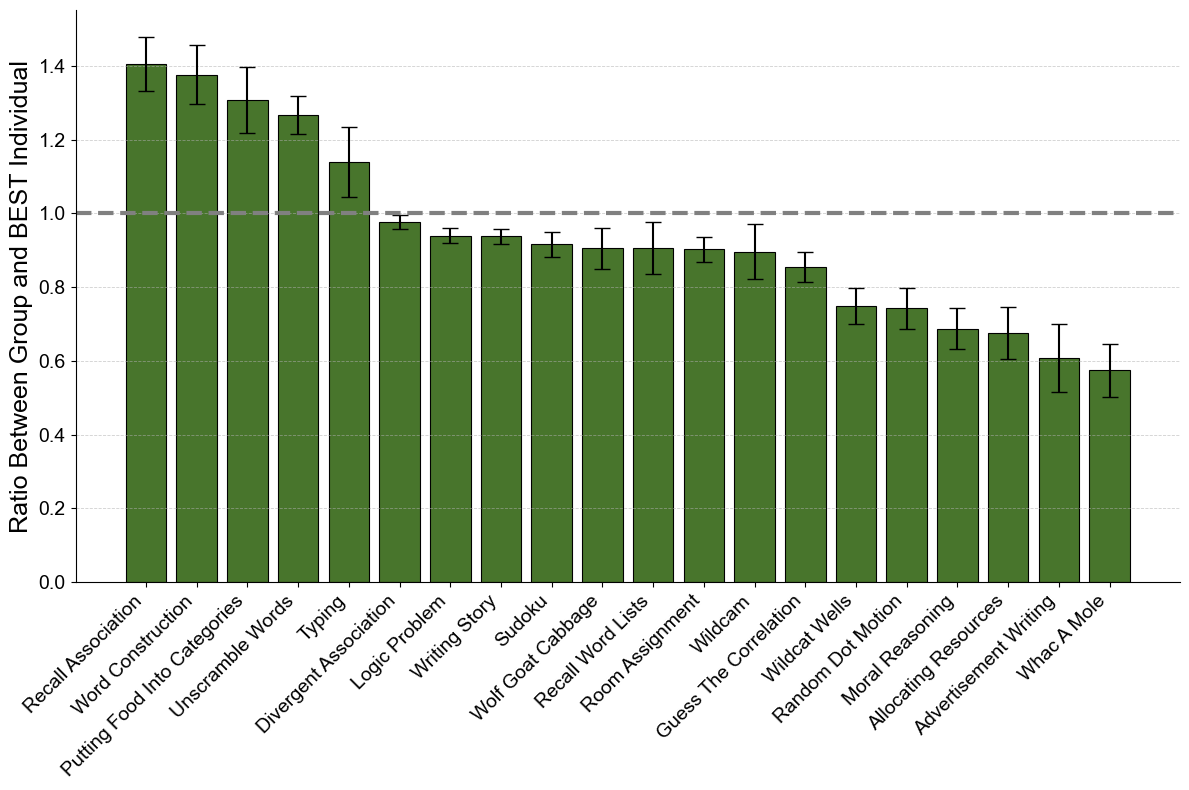

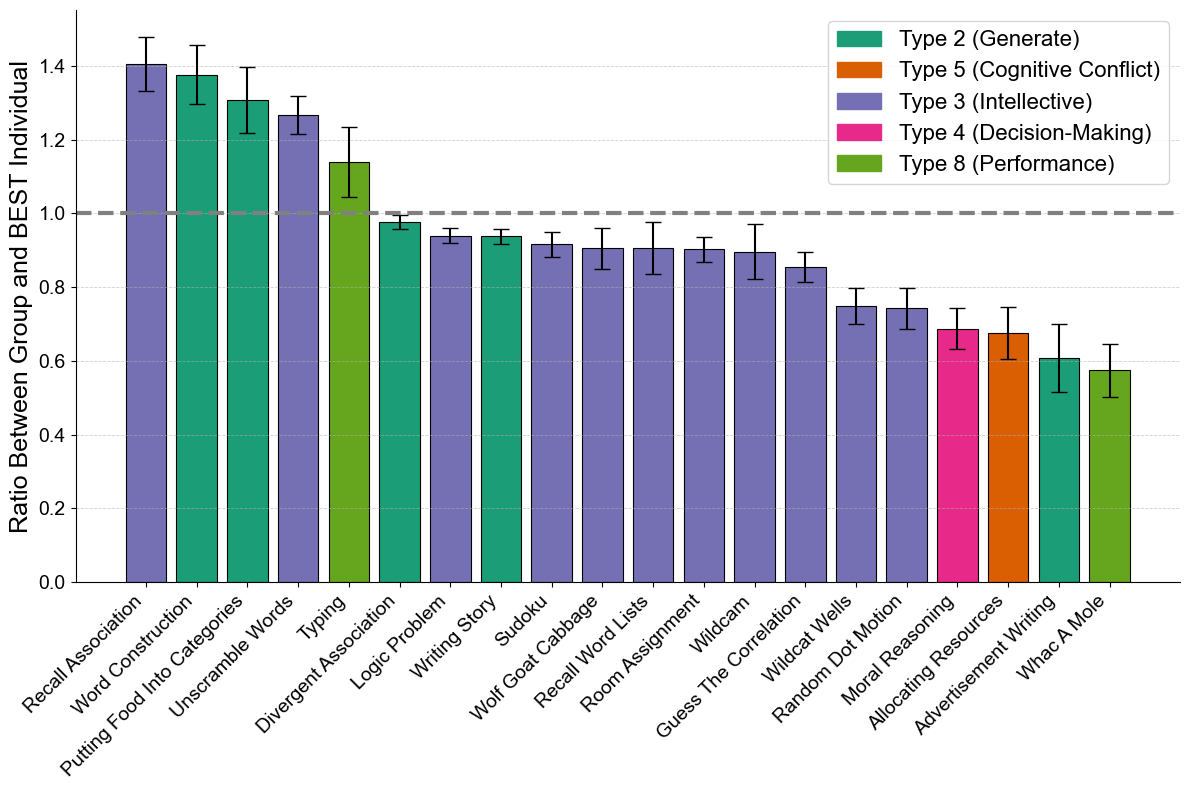

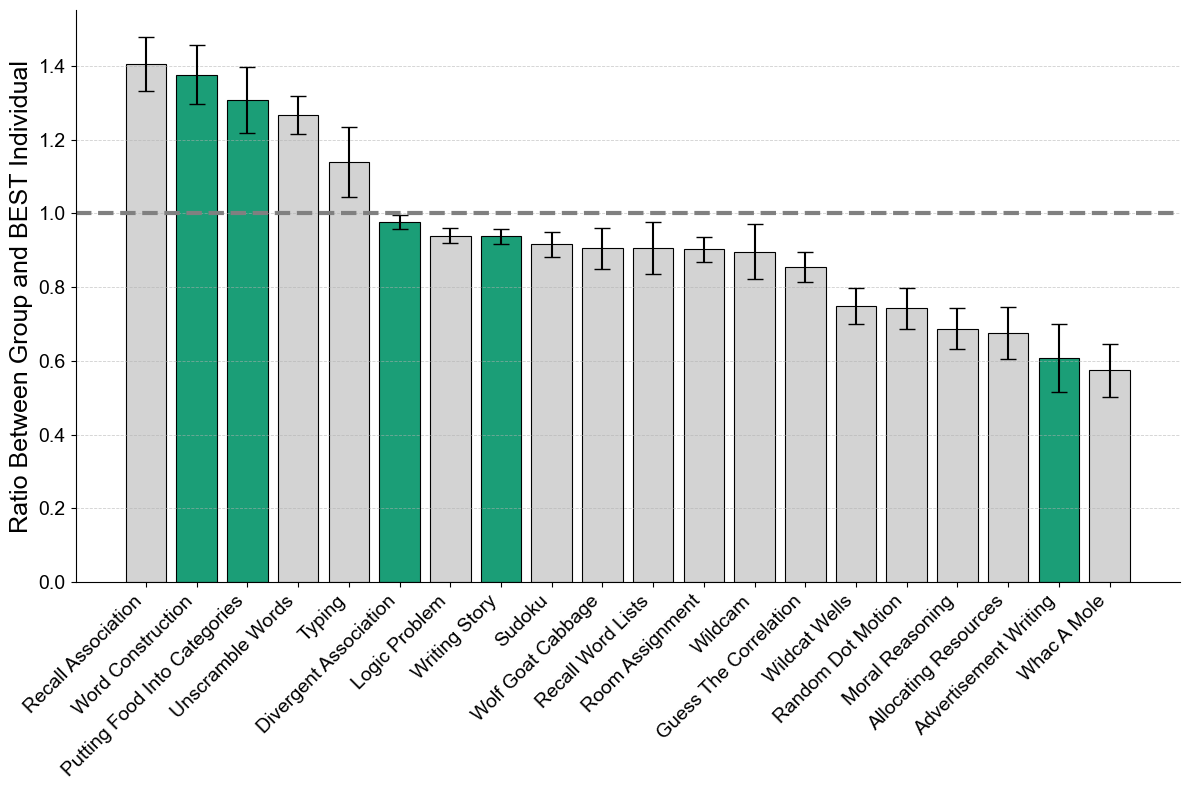

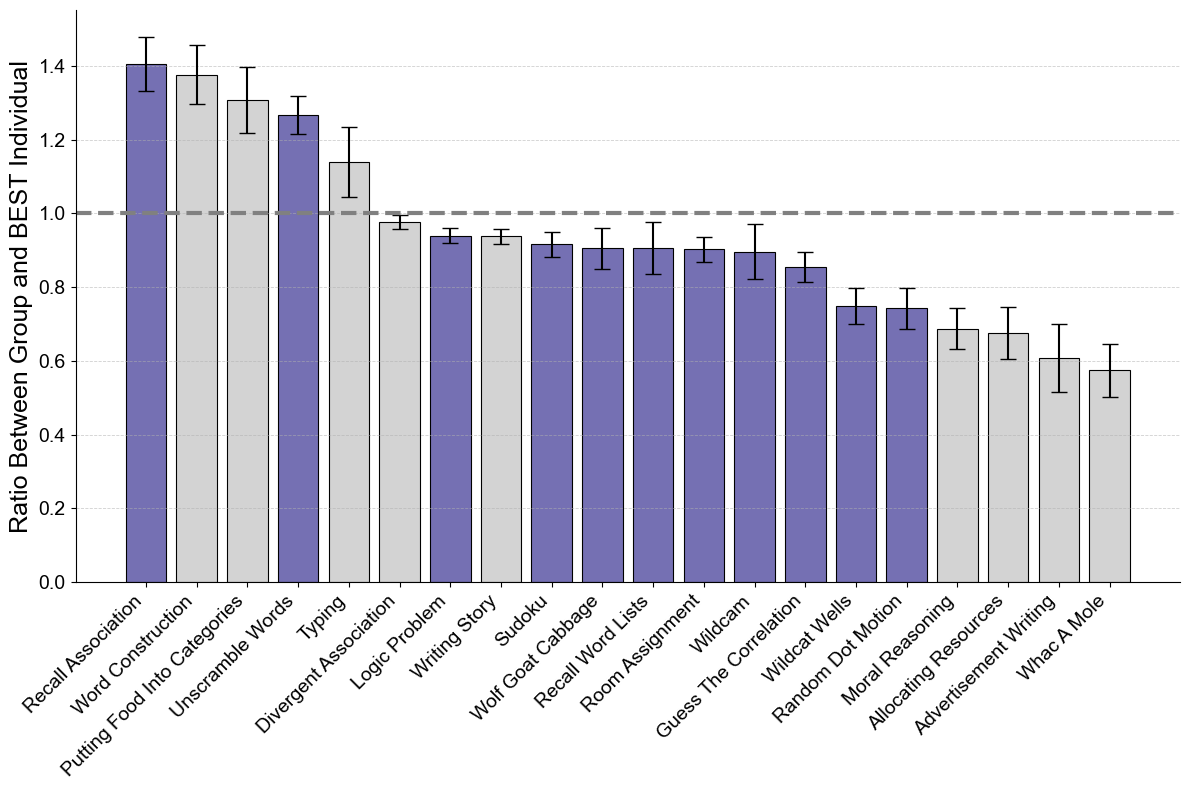

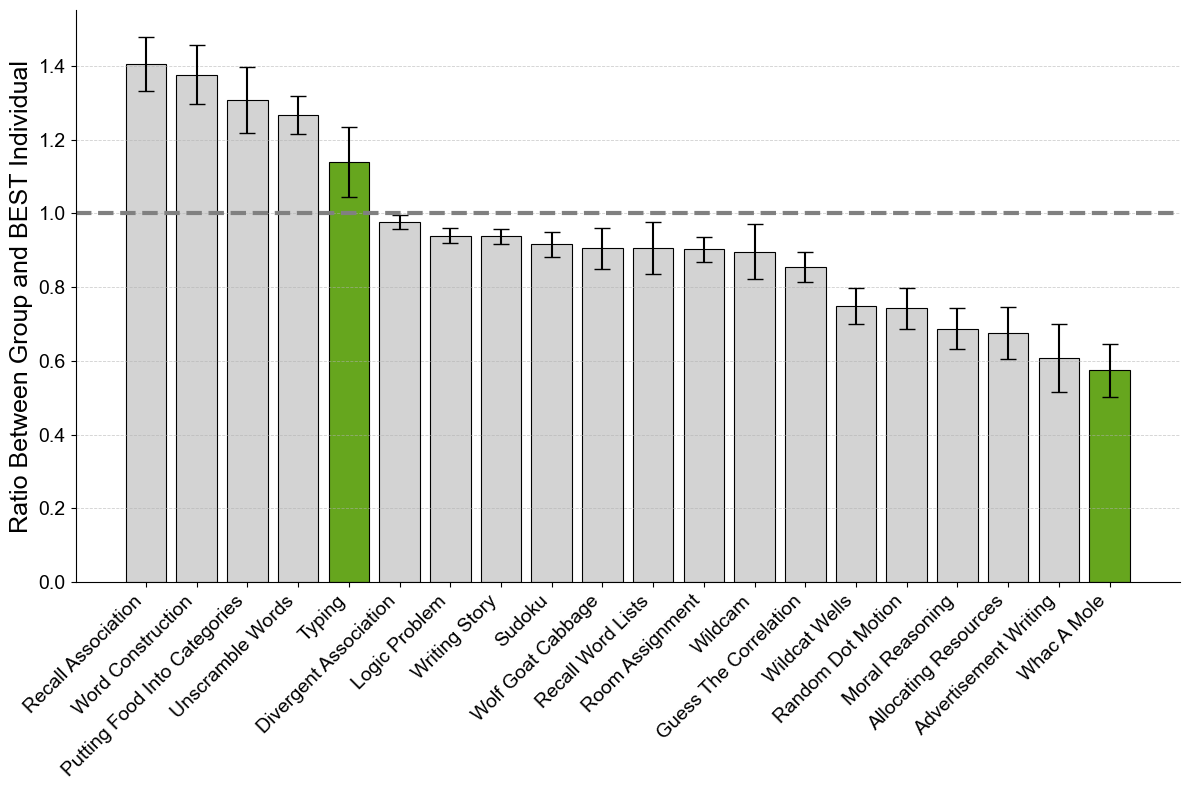

In [13]:
def plot_task_bars(
    df: pd.DataFrame,
    y_col: str = None,
    color_by_mcgrath: bool = False,
    highlight_type: Optional[str] = None,
):
    if y_col is None:
        candidates = [c for c in df.select_dtypes(include=[np.number]).columns if c != "task"]
        if not candidates:
            raise ValueError("No numeric columns found to plot.")
        y_col = candidates[0]

    d = df[["task", y_col]].dropna()

    def _ci_halfwidth(x):
        n = x.count()
        if n < 2:
            return 0.0
        sem = x.std(ddof=1) / np.sqrt(n)
        tcrit = stats.t.ppf(0.975, df=n-1)
        return tcrit * sem

    g = d.groupby("task", dropna=False)[y_col]
    summary = pd.DataFrame({
        "mean": g.mean(),
        "n": g.count(),
        "ci_half": g.apply(_ci_halfwidth)
    }).reset_index()

    # Handle McGrath coloring
    if color_by_mcgrath and "McGrath_Type" in df.columns:
        mcgrath_map = df.groupby("task")["McGrath_Type"].first()
        summary = summary.merge(mcgrath_map, on="task", how="left")

        # assign "default" colors first
        unique_types = summary["McGrath_Type"].unique()
        base_colors = list(plt.cm.Dark2.colors)
        color_cycle = itertools.cycle(base_colors)
        default_lookup = {t: next(color_cycle) for t in unique_types}

        if highlight_type is not None:
            highlight_type = str(highlight_type).lower()
            match = next(
                (t for t in unique_types if highlight_type in t.lower()),
                None
            )
            if match is None:
                raise ValueError(f"No McGrath type found matching '{highlight_type}'")

            # keep the original Dark2 color for the highlight type
            highlight_color = default_lookup[match]
            summary["color"] = summary["McGrath_Type"].apply(
                lambda t: highlight_color if t == match else "lightgray"
            )

            # no legend when highlighting
            color_lookup = {match: highlight_color, "Other": "lightgray"}
            show_legend = False
        else:
            # normal mode: keep all categories distinct
            summary["color"] = summary["McGrath_Type"].map(default_lookup)
            color_lookup = default_lookup
            show_legend = True

    else:
        summary["color"] = "#48752C"
        color_lookup = {}

    # sort by mean, descending
    summary = summary.sort_values("mean", ascending=False)

    plt.style.use("default")
    plt.rcParams.update({
        "font.family": "Arial",
        "axes.titlesize": 22,
        "axes.labelsize": 18,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    })

    fig, ax = plt.subplots(figsize=(12, 8))
    x = np.arange(len(summary))
    ax.bar(
        x, summary["mean"].values,
        yerr=summary["ci_half"].values,
        capsize=6,
        linewidth=0.8,
        edgecolor="black",
        color=summary["color"].values
    )

    ax.axhline(y=1, color="grey", linestyle="--", linewidth=3)

    if y_col == "strong":
        ylabel = "Ratio Between Group and BEST Individual"
    elif y_col == "weak":
        ylabel = "Ratio Between Group and WORST Individual"
    else:
        ylabel = y_col
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(summary["task"].astype(str).str.title(), rotation=45, ha="right")

    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if color_by_mcgrath and "McGrath_Type" in summary.columns:
        if highlight_type is not None:
            handles = [
                plt.Rectangle((0,0),1,1, color=color_lookup[match]),
                plt.Rectangle((0,0),1,1, color="lightgray"),
            ]
        else:
            handles = [plt.Rectangle((0,0),1,1, color=color_lookup[t]) for t in color_lookup]
            ax.legend(handles, color_lookup.keys(), loc="best", fontsize=16)

    plt.tight_layout()
    plt.show()


plot_task_bars(df_observation_level_data_with_mcgrath_types, "strong")
plot_task_bars(df_observation_level_data_with_mcgrath_types, "strong", color_by_mcgrath=True)
plot_task_bars(df_observation_level_data_with_mcgrath_types, "strong", color_by_mcgrath=True, highlight_type="Generate")
plot_task_bars(df_observation_level_data_with_mcgrath_types, "strong", color_by_mcgrath=True, highlight_type="Intellect")
plot_task_bars(df_observation_level_data_with_mcgrath_types, "strong", color_by_mcgrath=True, highlight_type="Performance")

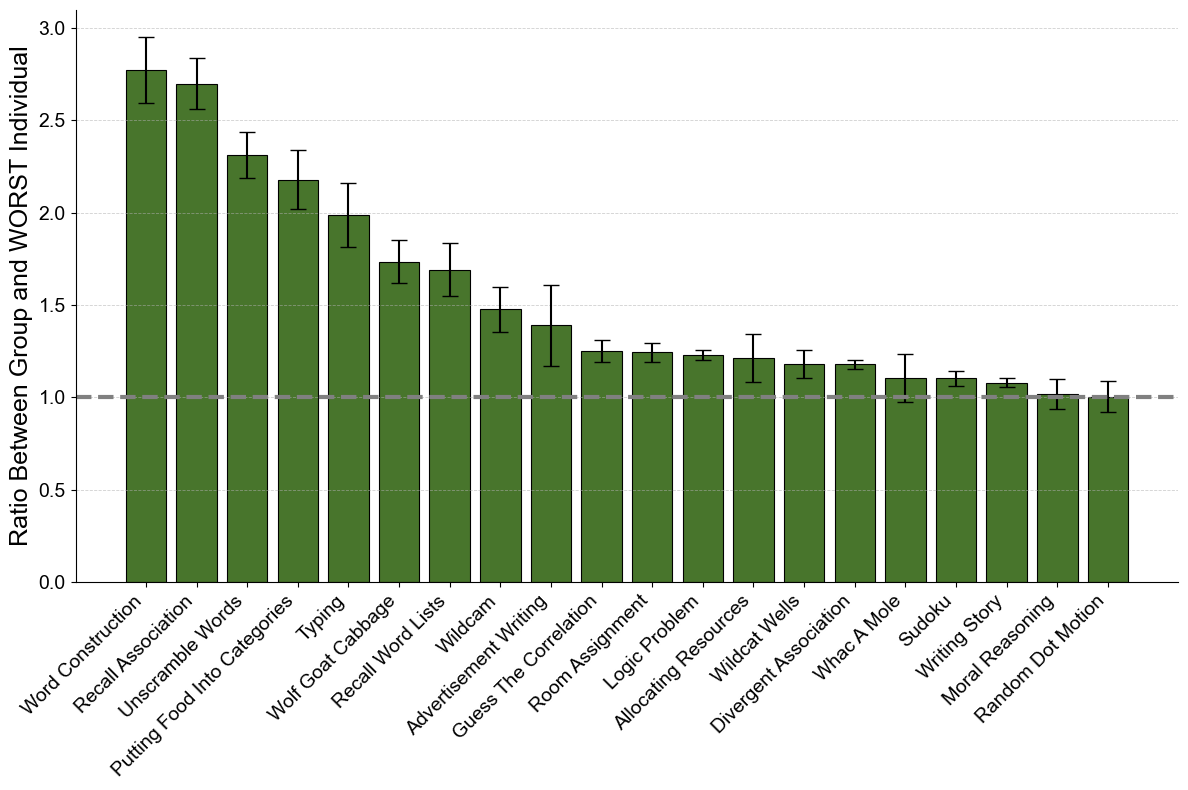

In [14]:
plot_task_bars(df_observation_level_data_with_mcgrath_types, "weak")

In [15]:
df_sum_adjusted_tasks = pd.read_csv('../outputs/deduplicated_sum_synergy_df.csv')

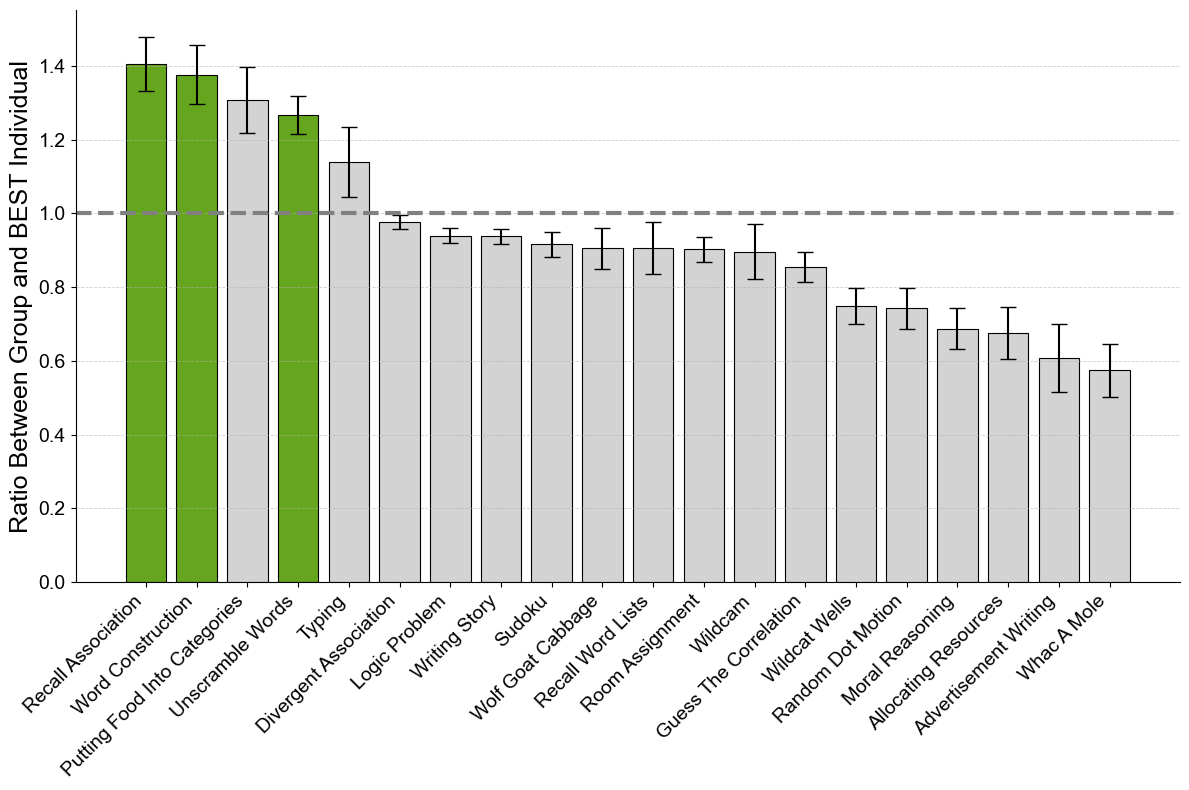

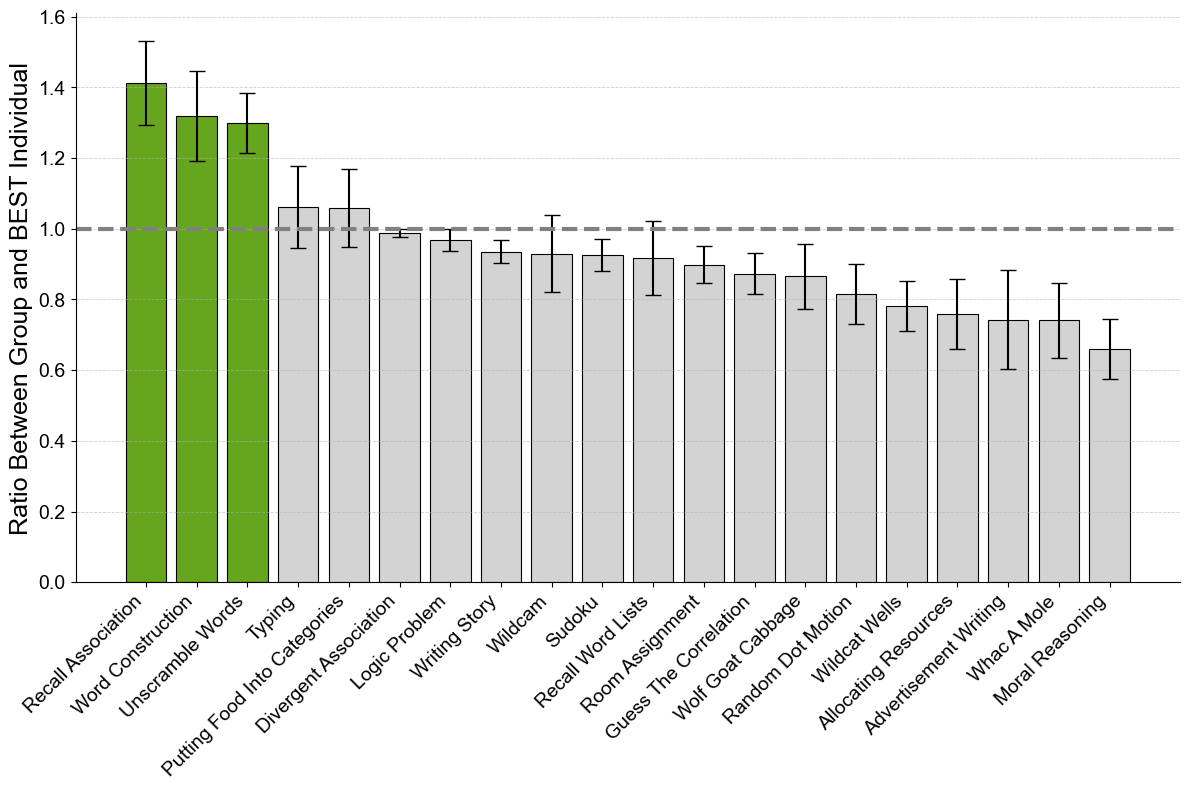

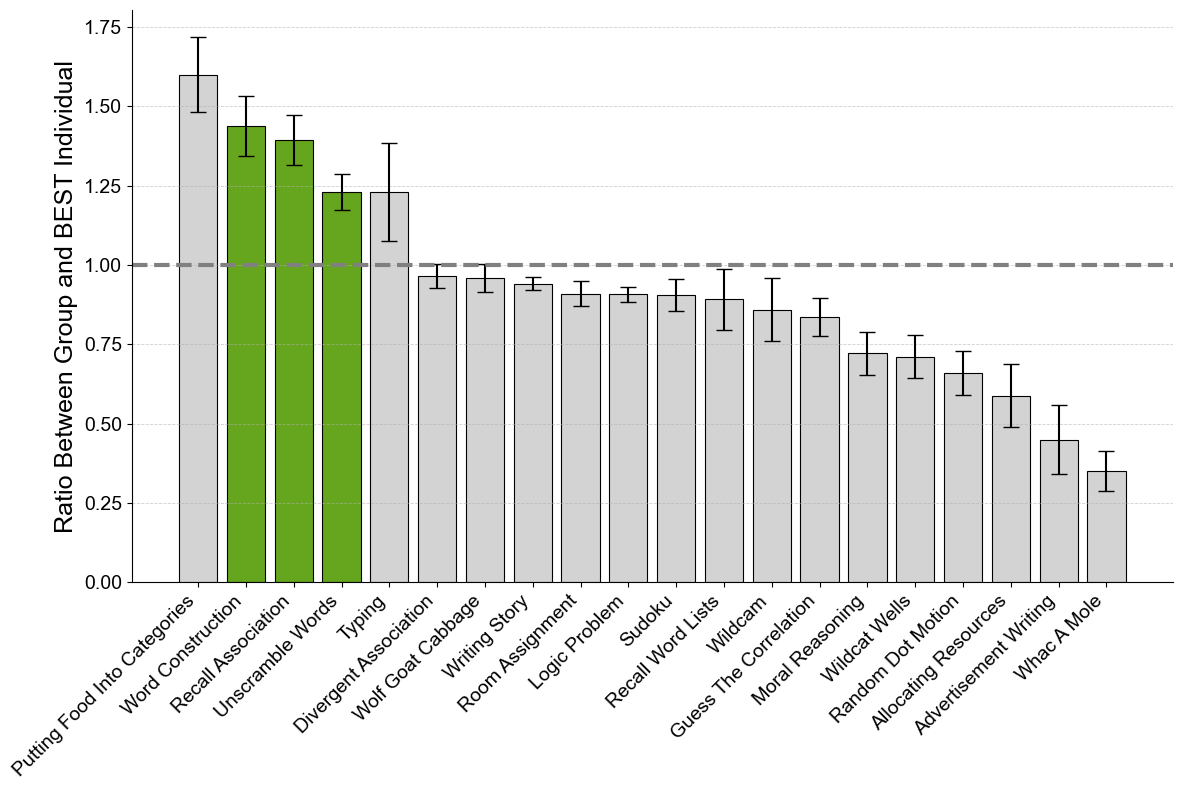

In [16]:
df_obs_with_sum_nonadjusted_highlighted = df_observation_level_data_with_mcgrath_types.copy()
tasks_to_replace = df_sum_adjusted_tasks['task'].unique()
for task in tasks_to_replace:
    stage_ids_for_task = df_sum_adjusted_tasks[df_sum_adjusted_tasks['task'] == task]['stageId'].unique()
    for stage_id in stage_ids_for_task:
        mask = (df_obs_with_sum_nonadjusted_highlighted['stageId'] == stage_id) & (df_obs_with_sum_nonadjusted_highlighted['task'] == task)
        df_obs_with_sum_nonadjusted_highlighted.loc[mask, "McGrath_Type"] = "Sum-Adjusted"

plot_task_bars(df_obs_with_sum_nonadjusted_highlighted, "strong", color_by_mcgrath=True, highlight_type="Sum")

df_obs_with_sum_nonadjusted_highlighted_3_player = df_obs_with_sum_nonadjusted_highlighted[df_obs_with_sum_nonadjusted_highlighted['playerCount'] == 3]
df_obs_with_sum_nonadjusted_highlighted_6_player = df_obs_with_sum_nonadjusted_highlighted[df_obs_with_sum_nonadjusted_highlighted['playerCount'] == 6]

plot_task_bars(df_obs_with_sum_nonadjusted_highlighted_3_player, "strong", color_by_mcgrath=True, highlight_type="Sum")
plot_task_bars(df_obs_with_sum_nonadjusted_highlighted_6_player, "strong", color_by_mcgrath=True, highlight_type="Sum")


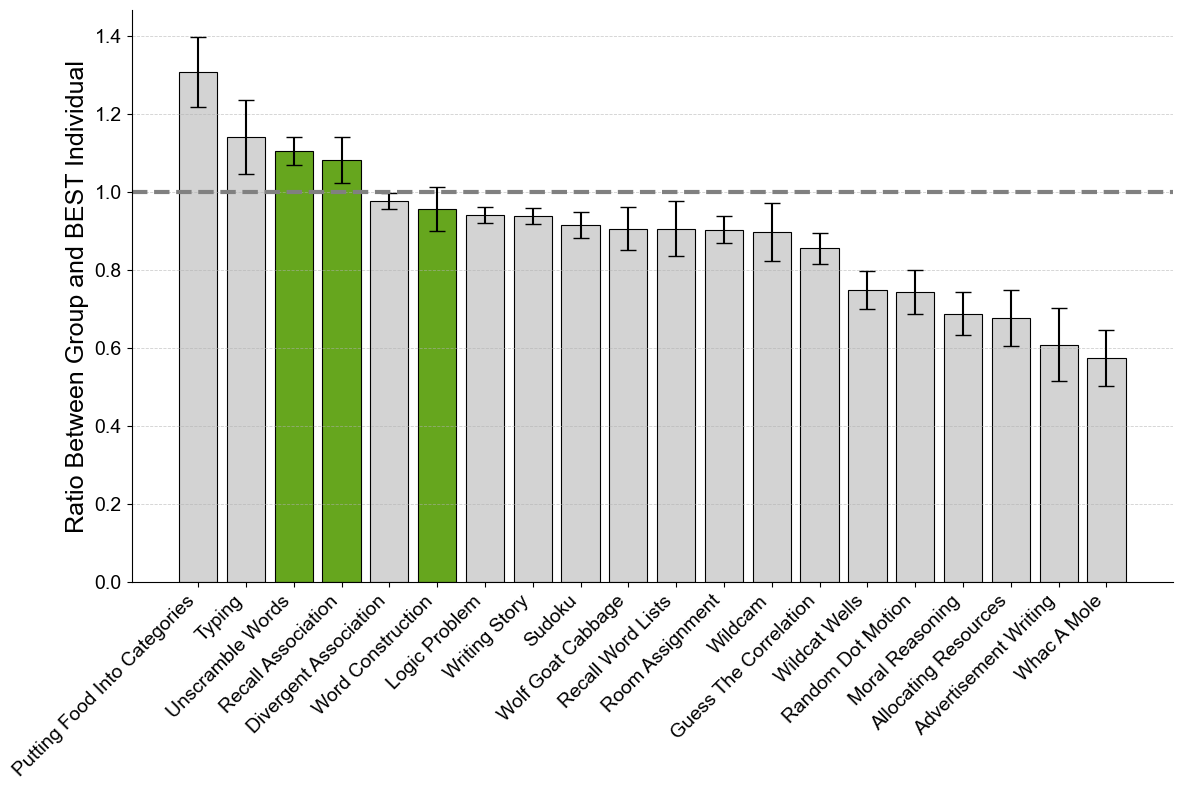

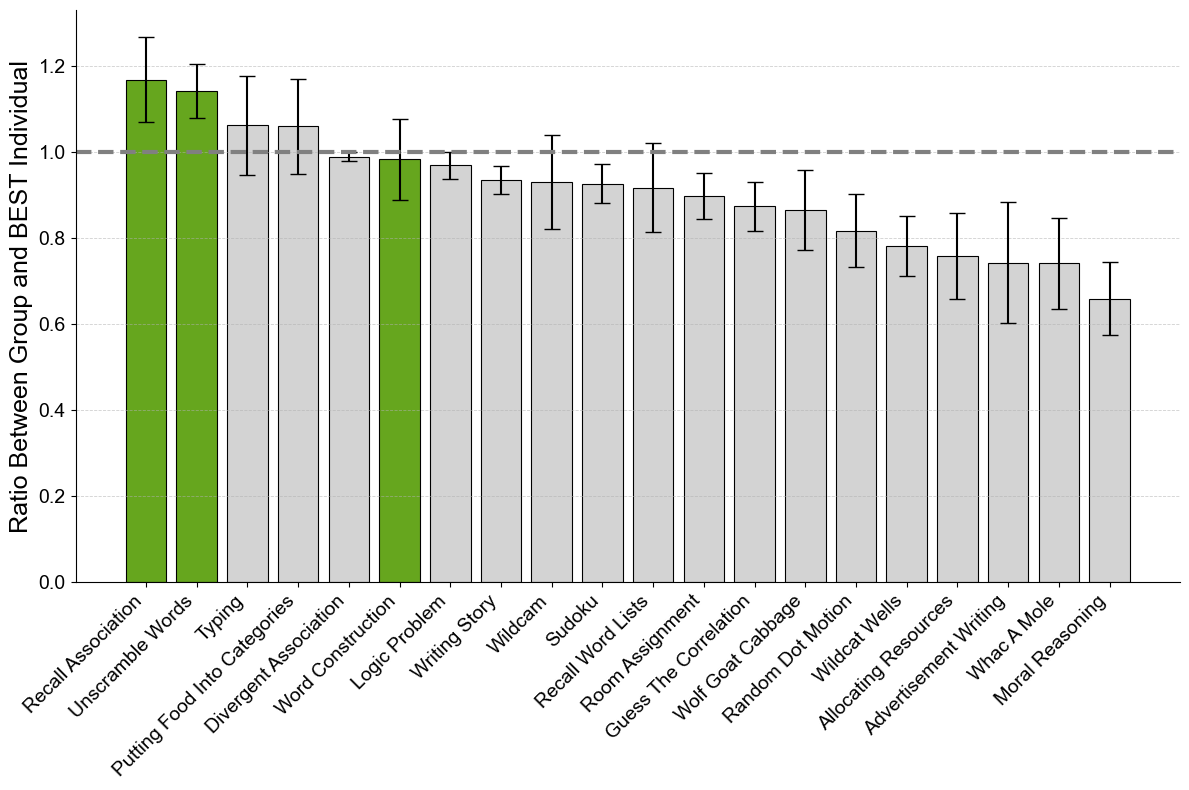

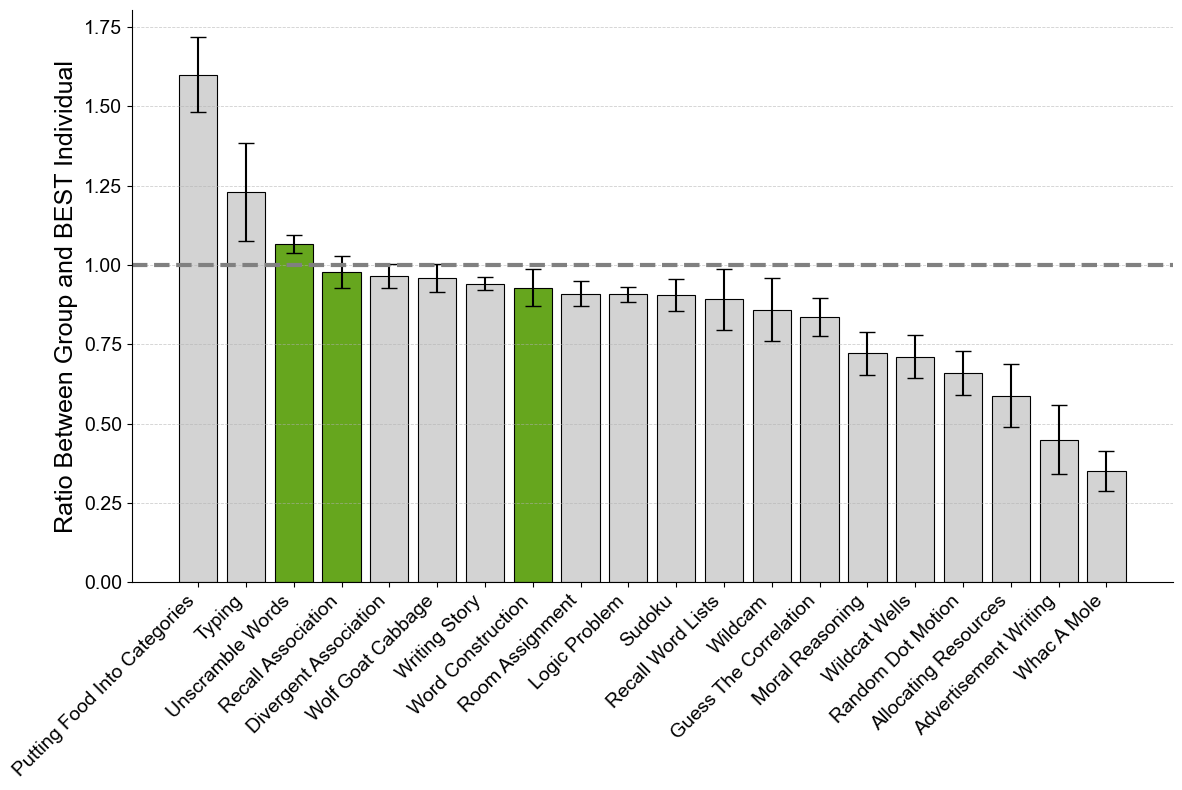

In [17]:
df_obs_level_with_sum_adjustments = df_observation_level_data_with_mcgrath_types.copy()
dv_to_replace = "strong" # compare it against the "strong" column
# for the following tasks, replace the `dv_to_replace` column with the corresponding value from "normalized_score" in df_sum_adjusted_tasks, matching with "stageId"
tasks_to_replace = df_sum_adjusted_tasks['task'].unique()

for task in tasks_to_replace:
    stage_ids_for_task = df_sum_adjusted_tasks[df_sum_adjusted_tasks['task'] == task]['stageId'].unique()
    for stage_id in stage_ids_for_task:
        mask = (df_obs_level_with_sum_adjustments['stageId'] == stage_id) & (df_obs_level_with_sum_adjustments['task'] == task)
        replacement_values = df_sum_adjusted_tasks[(df_sum_adjusted_tasks['task'] == task) & (df_sum_adjusted_tasks['stageId'] == stage_id)][['normalized_score']].values
        if len(replacement_values) > 0:
            df_obs_level_with_sum_adjustments.loc[mask, dv_to_replace] = replacement_values[0][0]
        # also replace the "McGrath Type" column to "Sum-Adjusted"
        df_obs_level_with_sum_adjustments.loc[mask, "McGrath_Type"] = "Sum-Adjusted"

# now plot it against strong synergy in all the other tasks
plot_task_bars(df_obs_level_with_sum_adjustments, "strong", color_by_mcgrath=True, highlight_type="Sum")

# split by player count
df_obs_level_with_sum_adjustments_3_player = df_obs_level_with_sum_adjustments[df_obs_level_with_sum_adjustments['playerCount'] == 3]
df_obs_level_with_sum_adjustments_6_player = df_obs_level_with_sum_adjustments[df_obs_level_with_sum_adjustments['playerCount'] == 6]  

plot_task_bars(df_obs_level_with_sum_adjustments_3_player, "strong", color_by_mcgrath=True, highlight_type="Sum")
plot_task_bars(df_obs_level_with_sum_adjustments_6_player, "strong", color_by_mcgrath=True, highlight_type="Sum")

# Run Models

### Data Structure for Storing the Final Models & Outputs

In [18]:
base_model = {
			"OLS": {
				"Wave 1": {"strong": None, "weak": None},
				"Wave 2": {"strong": None, "weak": None}
			},
			"E-Net": {
				"Wave 1": {"strong": None, "weak": None},
				"Wave 2": {"strong": None, "weak": None}
			}
		}

In [19]:
try:
	# read the models and results from the previous save
	with open('../outputs/models_observational.pkl', 'rb') as f:
		MODELS = pickle.load(f)
	with open('../outputs/model_r2_results_observational.pkl', 'rb') as f:
		MODEL_R2_RESULTS = pickle.load(f)
	with open('../outputs/model_rmse_results_observational.pkl', 'rb') as f:
		MODEL_RMSE_RESULTS = pickle.load(f)

except FileNotFoundError:
	# if the file is not found, we will create the MODELS and MODEL_R2_RESULTS dictionaries
	MODELS = {
		"Task Space": copy.deepcopy(base_model),
		"McGrath Categorical": copy.deepcopy(base_model),
		"McGrath Subspace": copy.deepcopy(base_model)
	}

	# create a dictionary with the same keys as MODELS to store R2 results
	MODEL_R2_RESULTS = copy.deepcopy(MODELS)

	# create a dictionary with the same keys as MODELS to store RMSE results
	MODEL_RMSE_RESULTS = copy.deepcopy(MODELS)

In [20]:
# save MODELS and MODEL_R2_RESULTS
def save_current_model_and_results_version(MODELS, MODEL_R2_RESULTS, MODEL_RMSE_RESULTS):
	with open('../outputs/models_observational.pkl', 'wb') as f:
		pickle.dump(MODELS, f)
	with open('../outputs/model_r2_results_observational.pkl', 'wb') as f:
		pickle.dump(MODEL_R2_RESULTS, f)
	with open('../outputs/model_rmse_results_observational.pkl', 'wb') as f:
		pickle.dump(MODEL_RMSE_RESULTS, f)

In [21]:
save_current_model_and_results_version(MODELS, MODEL_R2_RESULTS, MODEL_RMSE_RESULTS)

# Linear Models 
(with random coefficients for the team and ordering controls)

In [22]:
# Hold out 10 tasks
wave1_df_train = df_observation_level_data_with_mcgrath_types[df_observation_level_data_with_mcgrath_types["wave"] == 1] ## train on this
wave1_df_test = df_observation_level_data_with_mcgrath_types[df_observation_level_data_with_mcgrath_types["wave"] > 1] ## test on everything else

# Hold out 5 tasks
wave12_df_train = df_observation_level_data_with_mcgrath_types[df_observation_level_data_with_mcgrath_types["wave"] <= 2] ## then train on this
wave12_df_test = df_observation_level_data_with_mcgrath_types[df_observation_level_data_with_mcgrath_types["wave"] == 3] ## test on everything else

In [23]:
# datastructure for the training and testing data
TRAIN_TEST_DATA = {
	"Wave 1": {
		"train": wave1_df_train,
		"test": wave1_df_test
	},
	"Wave 2": {
		"train": wave12_df_train,	
		"test": wave12_df_test
	}
}

# save TRAIN_TEST_DATA as a pickle file
with open('../outputs/train_test_data_observational.pkl', 'wb') as f:
	pickle.dump(TRAIN_TEST_DATA, f)

In [24]:
# lists of IV's
TEAM_ID = "playerIds"
CONTROLS = ["playerCount", "Low", "Medium", "High", "ordering", "stage_index", "round_index"]

basic_IVs = [col for col in df_observation_level_data_with_mcgrath_types.columns if 
	"displayName" not in col and "complexity" not in col and "McGrath_Type" not in col and
	"Type 6 (Mixed-Motive)" not in col and 
	"Id" not in col and not any(col.startswith(prefix) for prefix in ALL_DEMOGRAPHIC_COLS) and
	"categorical" not in col and "task" not in col and "strong" not in col and "weak" not in col and "wave" not in col]

mcgrath_continuous = [col for col in basic_IVs if "Type" in col] + ["Conceptual-Behavioral"] + CONTROLS

categorical_IVs = [col for col in df_observation_level_data_with_mcgrath_types.columns if "categorical" in col] + CONTROLS

# save the lists of IVs
with open('../outputs/iv_lists_observational.pkl', 'wb') as f:
	pickle.dump({
		"basic_IVs": basic_IVs,
		"mcgrath_continuous": mcgrath_continuous,
		"categorical_IVs": categorical_IVs
	}, f)

Print out the independent variables to verify what they are:

In [25]:
pprint.pprint({
		"basic_IVs": basic_IVs,
		"mcgrath_continuous": mcgrath_continuous,
		"categorical_IVs": categorical_IVs
	})

{'basic_IVs': ['round_index',
               'ordering',
               'stage_index',
               'playerCount',
               'Conceptual-Behavioral',
               'Type 1 (Planning)',
               'Type 2 (Generate)',
               'Type 5 (Cognitive Conflict)',
               'Type 7 (Battle)',
               'Type 8 (Performance)',
               'Divisible-Unitary',
               'Maximizing',
               'Optimizing',
               'Outcome Multiplicity',
               'Solution Scheme Multiplicity',
               'Decision Verifiability',
               'Shared Knowledge',
               'Within-System Solution',
               'Answer Recognizability',
               'Time Solvability',
               'Type 3 and Type 4 (Objective Correctness)',
               'Conflicting Tradeoffs',
               'Solution Scheme Outcome Uncertainty',
               'Eureka Question',
               'Intellectual-Manipulative',
               'Intellective-Judgmental',
     

Functions to train on one wave and test on another

In [26]:
# -----------------------------
# Metrics
# -----------------------------
def get_rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def custom_r2(y_pred, y_actual, wave_a_data, wave_b_data, dv_type):
    """
    Test R^2 relative to your training-derived baseline per playerCount and complexity one-hots.
    """
    naive_prediction_errs = []
    for _, row in wave_b_data.iterrows():
        playerCount = row["playerCount"]
        subset = wave_a_data[
            (wave_a_data["playerCount"] == playerCount)
            & (wave_a_data["Low"] == row["Low"])
            & (wave_a_data["Medium"] == row["Medium"])
            & (wave_a_data["High"] == row["High"])
        ]
        y_training = np.mean(subset[dv_type]) if len(subset) > 0 else np.mean(wave_a_data[dv_type])
        naive_prediction_errs.append((row[dv_type] - y_training) ** 2)
    denom = np.sum(naive_prediction_errs)
    if denom == 0:
        return np.nan
    return 1 - np.sum((np.asarray(y_pred) - np.asarray(y_actual)) ** 2) / denom


# -----------------------------
# Simple formula builder
# -----------------------------
def build_simple_formula(dv, ivs, train_df):
    """
    Build a simple Patsy formula from ivs:
      - 'complexity' -> C(complexity, ref='Low', fixed levels)
      - 'McGrath_Type' -> C(McGrath_Type, Sum) with levels fixed to training data
      - All other ivs used as continuous (quoted)
      - Exclude *_categorical placeholders, 'Low','Medium','High' and 'ordering' from fixed effects
    Returns (formula_str, used_mcgrath_flag)
    """
    assert dv in train_df.columns, f"DV {dv} not found in training data."

    # Clean IVs: remove placeholders and things we never want in FE
    base_ivs = [v for v in ivs if not str(v).endswith("_categorical") and v not in ("Low", "Medium", "High", "ordering")]
    use_complexity = "complexity" in base_ivs
    use_mcgrath = "McGrath_Type" in base_ivs

    cont = [v for v in base_ivs if v not in ("complexity", "McGrath_Type")]

    rhs_terms = [f'Q("{c}")' for c in cont]

    if use_complexity:
        rhs_terms.append('C(complexity, Treatment(reference="Low"), levels=["Low","Medium","High"])')

    if use_mcgrath:
        levels = pd.Index(train_df["McGrath_Type"].dropna().unique()).tolist()
        levels_str = ",".join([f'"{lv}"' for lv in levels])
        rhs_terms.append(f'C(McGrath_Type, Sum, levels=[{levels_str}])')

    rhs = " + ".join(rhs_terms) if rhs_terms else "1"
    formula = f'Q("{dv}") ~ {rhs}'
    return formula, use_mcgrath


# -----------------------------
# Train, predict, and plotting
# -----------------------------
def train_wave_a(wave_a_data, dv_type, ivs, complexity_ref="Low", verbose=True):
    """
    Fit a MixedLM:
      - Fixed effects = ivs (with categorical treatment for complexity; Sum for McGrath_Type when present)
      - Random intercept per TEAM_ID (global string naming the ID column)
      - Variance component for 'ordering' (if present): vc_formula={"ordering": "0 + C(ordering)"}
    Prints the specification and basic results.
    """
    assert dv_type in ["strong", "weak"]
    if "complexity" not in wave_a_data.columns:
        raise ValueError("Missing 'complexity' column in training data.")
    if TEAM_ID not in wave_a_data.columns:
        raise ValueError(f"Missing TEAM_ID column '{TEAM_ID}' in training data.")

    formula, use_mcgrath = build_simple_formula(dv_type, ivs, wave_a_data)

    # Human-readable spec print
    spec_bits = []
    # repeat logic to show content in compact form
    base_ivs = [v for v in ivs if not str(v).endswith("_categorical") and v not in ("Low","Medium","High","ordering")]
    cont = [v for v in base_ivs if v not in ("complexity","McGrath_Type")]
    if cont:
        spec_bits.append(" + ".join(cont))
    if "complexity" in base_ivs:
        spec_bits.append('C(complexity, ref="Low")')
    if "McGrath_Type" in base_ivs:
        spec_bits.append("C(McGrath_Type, Sum)")
    spec_str = " + ".join(spec_bits) if spec_bits else "1"

    n = len(wave_a_data)
    n_teams = wave_a_data[TEAM_ID].nunique()
    n_order = wave_a_data["ordering"].nunique() if "ordering" in wave_a_data.columns else 0
    print(f"Spec: {dv_type} ~ {spec_str}  |  N={n}, teams={n_teams}, orderings={n_order}")

    vc_formula = {"ordering": "0 + C(ordering)"} if "ordering" in wave_a_data.columns else None

    # Fit MixedLM via formula API
    md = MixedLM.from_formula(formula, groups=wave_a_data[TEAM_ID], vc_formula=vc_formula, data=wave_a_data)
    result = md.fit(reml=True, method="lbfgs")

    # Print FE results
    print("Fixed-effects coefficients:")
    print(result.fe_params.round(4).to_string())

    # For simple unseen-level handling at predict time
    result._used_mcgrath = use_mcgrath
    if use_mcgrath:
        train_levels = pd.Index(wave_a_data["McGrath_Type"].dropna().unique()).tolist()
        result._train_mcgrath_levels = train_levels
        if len(train_levels) > 0:
            result._mcgrath_fallback = wave_a_data["McGrath_Type"].mode().iloc[0]
        else:
            result._mcgrath_fallback = None
    return result

def _sanitize_test_for_predict(model, df):
    """
    Minimal pre-processing for predict:
      - If McGrath_Type was used and test has unseen levels, map them to the most frequent training level.
    """
    if getattr(model, "_used_mcgrath", False):
        levels = set(getattr(model, "_train_mcgrath_levels", []) or [])
        if "McGrath_Type" in df.columns and levels:
            mask = ~df["McGrath_Type"].isin(levels)
            if mask.any():
                fallback = getattr(model, "_mcgrath_fallback", None)
                unseen_vals = sorted(pd.Index(df.loc[mask, "McGrath_Type"].unique()).tolist())
                print(f"Warning: unseen McGrath_Type levels in test {unseen_vals}; mapping to '{fallback}' for prediction.")
                df = df.copy()
                df.loc[mask, "McGrath_Type"] = fallback
    return df

def plot_results(y_actual, y_pred, y_train, r2, title="Model Results"):
    min_val = 0
    max_val = max(round(max(y_actual.max(), y_pred.max()), 0), 0)
    plt.scatter(y_actual, y_pred)
    plt.axhline(y_train.mean(), color='r', linestyle='-')
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
    plt.text(0.1, 0.9, f"R^2 = {r2:.2f}", transform=plt.gca().transAxes, fontsize=14)
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

def test_wave_b(wave_a_data, wave_b_data, model, dv_type):
    """
    Predict on wave B using statsmodels' formula predict.
    """
    assert dv_type in ["strong", "weak"]
    if "complexity" not in wave_b_data.columns:
        raise ValueError("Missing 'complexity' column in test data.")

    wave_b_clean = _sanitize_test_for_predict(model, wave_b_data)
    y_actual = wave_b_clean[dv_type].values
    y_pred = model.predict(wave_b_clean)
    r2 = custom_r2(y_pred, y_actual, wave_a_data, wave_b_clean, dv_type)

    plot_results(y_actual, y_pred, wave_a_data[dv_type], r2, title=f"Wave B Prediction for {dv_type}")
    return r2, y_actual, y_pred

def train_wave_a_test_wave_b(wave_a_data, wave_b_data, dv_type, ivs, title, plot=False):
    """
    Train on wave A, test on wave B, return (model, r2).
    Prints spec and concise results for easy debugging.
    """
    model = train_wave_a(wave_a_data=wave_a_data, dv_type=dv_type, ivs=ivs, complexity_ref="Low", verbose=True)
    r2, y, y_pred = test_wave_b(wave_a_data, wave_b_data, model, dv_type)
    rmse = get_rmse(y, y_pred)
    print(f"Test metrics: R^2={r2:.3f}, RMSE={rmse:.3f}")
    if plot:
        plot_results(y, y_pred, wave_a_data[dv_type], r2, title)
    return model, r2

# -----------------------------
# RMSE helper
# -----------------------------
def get_rmse_ols(model, X_test_df, y_true, ivs):
    """
    For our MixedLM, use formula-based predict on sanitized test DF.
    """
    X_test_clean = _sanitize_test_for_predict(model, X_test_df)
    y_pred = model.predict(X_test_clean)
    return get_rmse(y_true, y_pred)

### Build our Linear Models

Training Task Space model for strong in Wave 1...
Spec: strong ~ round_index + stage_index + playerCount + Conceptual-Behavioral + Type 1 (Planning) + Type 2 (Generate) + Type 5 (Cognitive Conflict) + Type 7 (Battle) + Type 8 (Performance) + Divisible-Unitary + Maximizing + Optimizing + Outcome Multiplicity + Solution Scheme Multiplicity + Decision Verifiability + Shared Knowledge + Within-System Solution + Answer Recognizability + Time Solvability + Type 3 and Type 4 (Objective Correctness) + Conflicting Tradeoffs + Solution Scheme Outcome Uncertainty + Eureka Question + Intellectual-Manipulative + Intellective-Judgmental + Creativity Input + C(complexity, ref="Low")  |  N=1715, teams=118, orderings=8
Fixed-effects coefficients:
Intercept                                                                               -0.9623
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.Medium]   -0.0289
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "

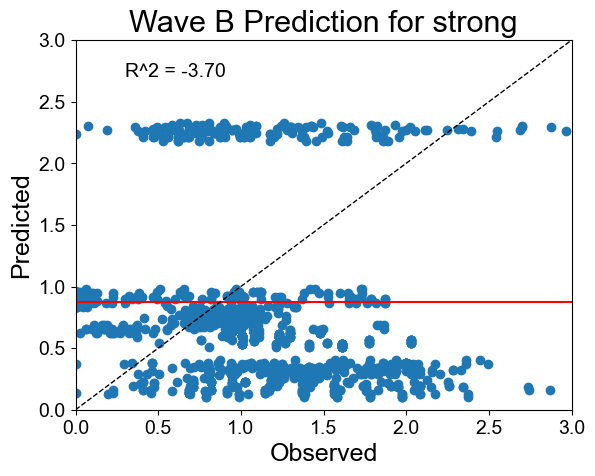

Test metrics: R^2=-3.703, RMSE=1.204
Training Task Space model for weak in Wave 1...
Spec: weak ~ round_index + stage_index + playerCount + Conceptual-Behavioral + Type 1 (Planning) + Type 2 (Generate) + Type 5 (Cognitive Conflict) + Type 7 (Battle) + Type 8 (Performance) + Divisible-Unitary + Maximizing + Optimizing + Outcome Multiplicity + Solution Scheme Multiplicity + Decision Verifiability + Shared Knowledge + Within-System Solution + Answer Recognizability + Time Solvability + Type 3 and Type 4 (Objective Correctness) + Conflicting Tradeoffs + Solution Scheme Outcome Uncertainty + Eureka Question + Intellectual-Manipulative + Intellective-Judgmental + Creativity Input + C(complexity, ref="Low")  |  N=1715, teams=118, orderings=8
Fixed-effects coefficients:
Intercept                                                                               -14.9623
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.Medium]    -0.1303
C(complexity, Treatment(reference

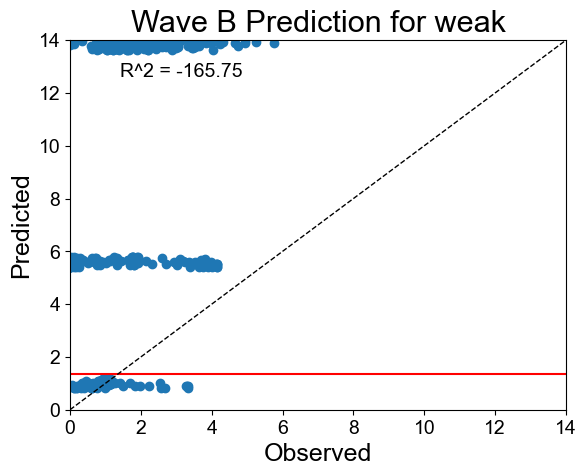

Test metrics: R^2=-165.753, RMSE=14.495
Training McGrath Categorical model for strong in Wave 1...
Spec: strong ~ playerCount + stage_index + round_index + C(complexity, ref="Low") + C(McGrath_Type, Sum)  |  N=1715, teams=118, orderings=8
Fixed-effects coefficients:
Intercept                                                                                                                                                                                     0.7657
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.Medium]                                                                                                        -0.0289
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.High]                                                                                                           0.0220
C(McGrath_Type, Sum, levels=["Type 2 (Generate)", "Type 4 (Decision-Making)", "Type 3 (Intellective)", "Type 8 (Performance)", "Type 5 (Cognit

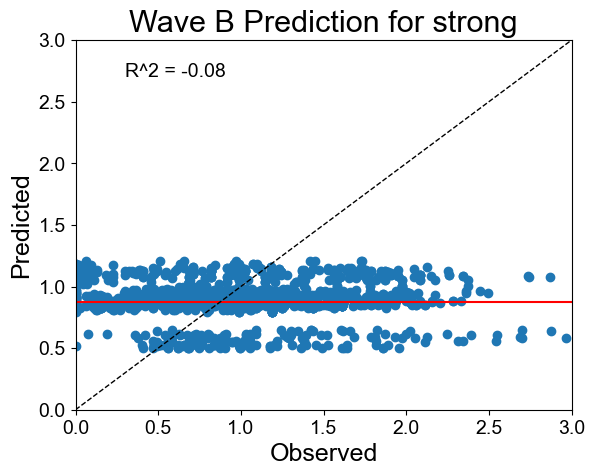

Test metrics: R^2=-0.080, RMSE=0.577
Training McGrath Categorical model for weak in Wave 1...
Spec: weak ~ playerCount + stage_index + round_index + C(complexity, ref="Low") + C(McGrath_Type, Sum)  |  N=1715, teams=118, orderings=8
Fixed-effects coefficients:
Intercept                                                                                                                                                                                     0.9283
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.Medium]                                                                                                        -0.1303
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.High]                                                                                                          -0.0121
C(McGrath_Type, Sum, levels=["Type 2 (Generate)", "Type 4 (Decision-Making)", "Type 3 (Intellective)", "Type 8 (Performance)", "Type 5 (Cognitive Con

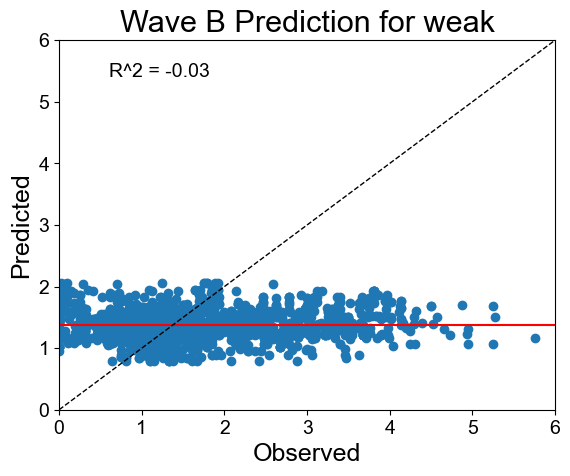

Test metrics: R^2=-0.028, RMSE=1.138
Training McGrath Subspace model for strong in Wave 1...
Spec: strong ~ Type 1 (Planning) + Type 2 (Generate) + Type 5 (Cognitive Conflict) + Type 7 (Battle) + Type 8 (Performance) + Type 3 and Type 4 (Objective Correctness) + Conceptual-Behavioral + playerCount + stage_index + round_index + C(complexity, ref="Low")  |  N=1715, teams=118, orderings=8
Fixed-effects coefficients:
Intercept                                                                                0.7198
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.Medium]   -0.0290
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.High]      0.0223
Q("Type 1 (Planning)")                                                                  -0.1626
Q("Type 2 (Generate)")                                                                   0.5767
Q("Type 5 (Cognitive Conflict)")                                                        -0.1357
Q("Type

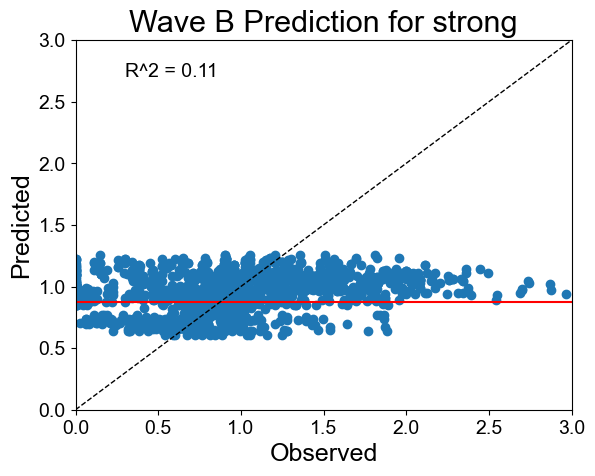

Test metrics: R^2=0.113, RMSE=0.523
Training McGrath Subspace model for weak in Wave 1...
Spec: weak ~ Type 1 (Planning) + Type 2 (Generate) + Type 5 (Cognitive Conflict) + Type 7 (Battle) + Type 8 (Performance) + Type 3 and Type 4 (Objective Correctness) + Conceptual-Behavioral + playerCount + stage_index + round_index + C(complexity, ref="Low")  |  N=1715, teams=118, orderings=8
Fixed-effects coefficients:
Intercept                                                                                0.1693
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.Medium]   -0.1304
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.High]     -0.0117
Q("Type 1 (Planning)")                                                                   0.3205
Q("Type 2 (Generate)")                                                                   2.0663
Q("Type 5 (Cognitive Conflict)")                                                         0.1351
Q("Type 7 (B

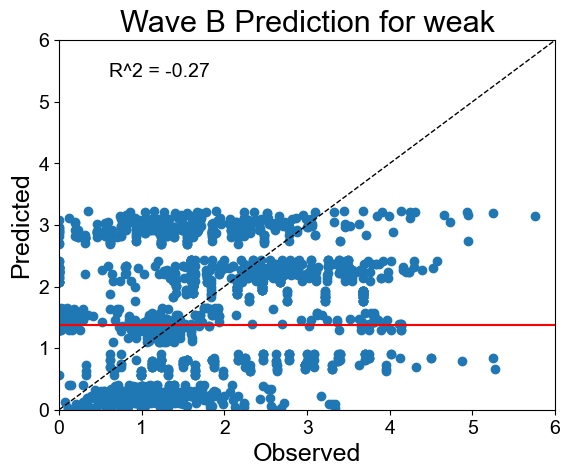

Test metrics: R^2=-0.267, RMSE=1.263
Training Task Space model for strong in Wave 2...
Spec: strong ~ round_index + stage_index + playerCount + Conceptual-Behavioral + Type 1 (Planning) + Type 2 (Generate) + Type 5 (Cognitive Conflict) + Type 7 (Battle) + Type 8 (Performance) + Divisible-Unitary + Maximizing + Optimizing + Outcome Multiplicity + Solution Scheme Multiplicity + Decision Verifiability + Shared Knowledge + Within-System Solution + Answer Recognizability + Time Solvability + Type 3 and Type 4 (Objective Correctness) + Conflicting Tradeoffs + Solution Scheme Outcome Uncertainty + Eureka Question + Intellectual-Manipulative + Intellective-Judgmental + Creativity Input + C(complexity, ref="Low")  |  N=2510, teams=171, orderings=11
Fixed-effects coefficients:
Intercept                                                                               -2.1126
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.Medium]   -0.0153
C(complexity, Treatment(refere

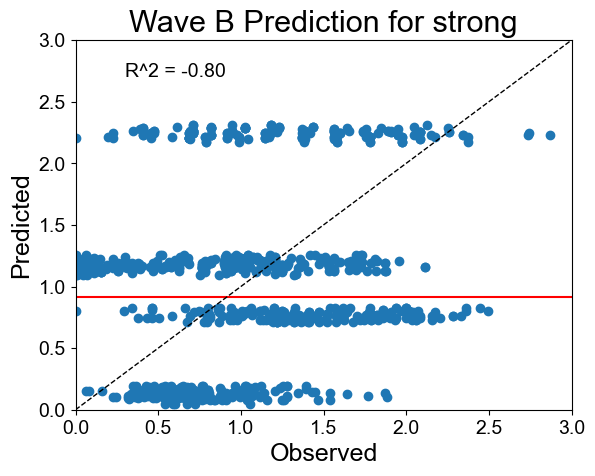

Test metrics: R^2=-0.803, RMSE=0.830
Training Task Space model for weak in Wave 2...
Spec: weak ~ round_index + stage_index + playerCount + Conceptual-Behavioral + Type 1 (Planning) + Type 2 (Generate) + Type 5 (Cognitive Conflict) + Type 7 (Battle) + Type 8 (Performance) + Divisible-Unitary + Maximizing + Optimizing + Outcome Multiplicity + Solution Scheme Multiplicity + Decision Verifiability + Shared Knowledge + Within-System Solution + Answer Recognizability + Time Solvability + Type 3 and Type 4 (Objective Correctness) + Conflicting Tradeoffs + Solution Scheme Outcome Uncertainty + Eureka Question + Intellectual-Manipulative + Intellective-Judgmental + Creativity Input + C(complexity, ref="Low")  |  N=2510, teams=171, orderings=11
Fixed-effects coefficients:
Intercept                                                                                1.4313
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.Medium]    0.0400
C(complexity, Treatment(reference=

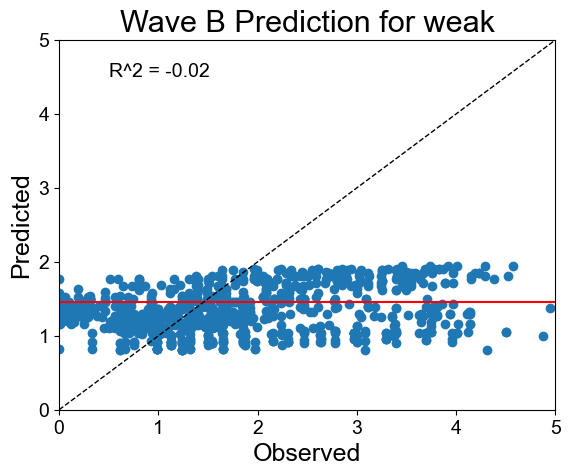

Test metrics: R^2=-0.021, RMSE=1.222
Training McGrath Categorical model for strong in Wave 2...
Spec: strong ~ playerCount + stage_index + round_index + C(complexity, ref="Low") + C(McGrath_Type, Sum)  |  N=2510, teams=171, orderings=11
Fixed-effects coefficients:
Intercept                                                                                                                                                                                     0.8240
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.Medium]                                                                                                        -0.0145
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.High]                                                                                                           0.0135
C(McGrath_Type, Sum, levels=["Type 3 (Intellective)", "Type 2 (Generate)", "Type 8 (Performance)", "Type 4 (Decision-Making)", "Type 5 (Cognitiv

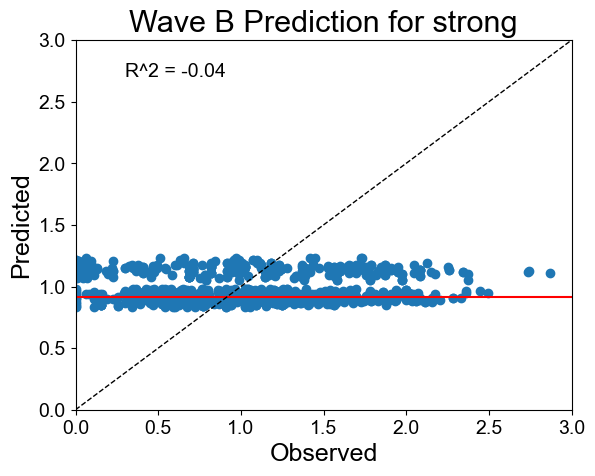

Test metrics: R^2=-0.038, RMSE=0.630
Training McGrath Categorical model for weak in Wave 2...
Spec: weak ~ playerCount + stage_index + round_index + C(complexity, ref="Low") + C(McGrath_Type, Sum)  |  N=2510, teams=171, orderings=11
Fixed-effects coefficients:
Intercept                                                                                                                                                                                     0.9931
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.Medium]                                                                                                         0.0415
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.High]                                                                                                           0.0709
C(McGrath_Type, Sum, levels=["Type 3 (Intellective)", "Type 2 (Generate)", "Type 8 (Performance)", "Type 4 (Decision-Making)", "Type 5 (Cognitive Co

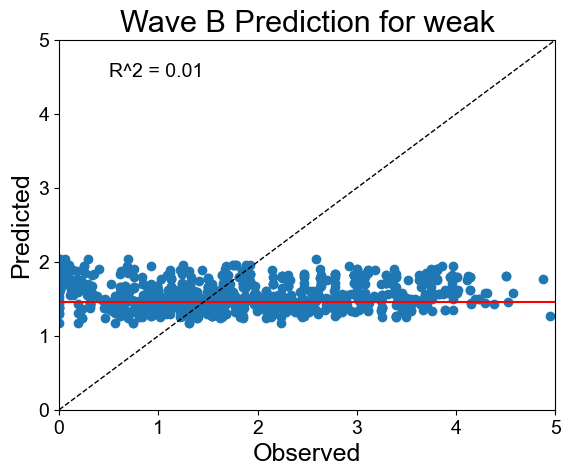

Test metrics: R^2=0.014, RMSE=1.201
Training McGrath Subspace model for strong in Wave 2...
Spec: strong ~ Type 1 (Planning) + Type 2 (Generate) + Type 5 (Cognitive Conflict) + Type 7 (Battle) + Type 8 (Performance) + Type 3 and Type 4 (Objective Correctness) + Conceptual-Behavioral + playerCount + stage_index + round_index + C(complexity, ref="Low")  |  N=2510, teams=171, orderings=11
Fixed-effects coefficients:
Intercept                                                                                0.5498
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.Medium]   -0.0152
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.High]      0.0132
Q("Type 1 (Planning)")                                                                  -0.1616
Q("Type 2 (Generate)")                                                                   0.7044
Q("Type 5 (Cognitive Conflict)")                                                        -0.0322
Q("Type

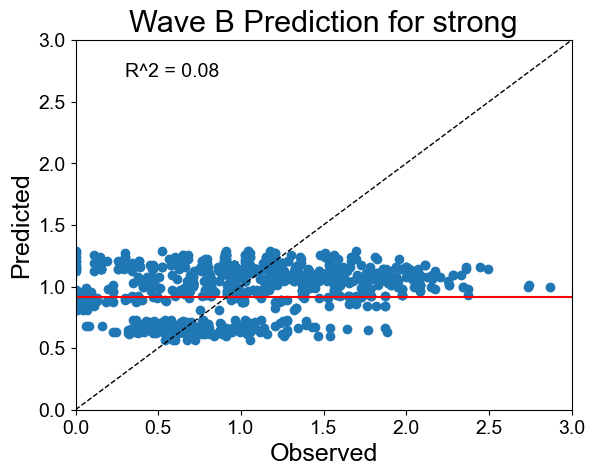

Test metrics: R^2=0.082, RMSE=0.593
Training McGrath Subspace model for weak in Wave 2...
Spec: weak ~ Type 1 (Planning) + Type 2 (Generate) + Type 5 (Cognitive Conflict) + Type 7 (Battle) + Type 8 (Performance) + Type 3 and Type 4 (Objective Correctness) + Conceptual-Behavioral + playerCount + stage_index + round_index + C(complexity, ref="Low")  |  N=2510, teams=171, orderings=11
Fixed-effects coefficients:
Intercept                                                                               -0.2759
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.Medium]    0.0395
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.High]      0.0699
Q("Type 1 (Planning)")                                                                  -0.1665
Q("Type 2 (Generate)")                                                                   1.8947
Q("Type 5 (Cognitive Conflict)")                                                         0.4858
Q("Type 7 (

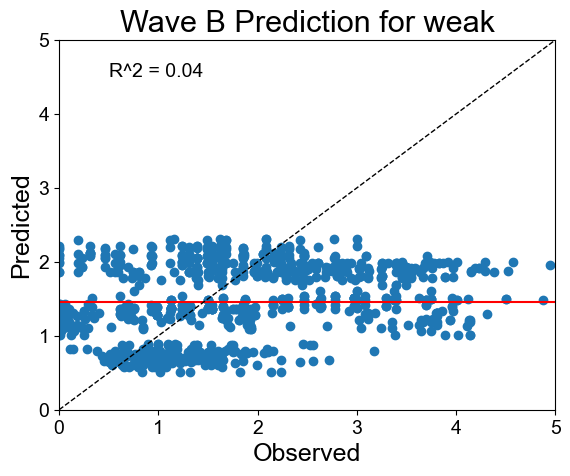

Test metrics: R^2=0.039, RMSE=1.185


In [27]:
for wave in TRAIN_TEST_DATA.keys():
	for model_type in MODELS.keys():
		for dv_type in ["strong", "weak"]:
			# if the model for this wave and dv_type is not trained yet, train it
			if not MODELS[model_type]["OLS"][wave][dv_type] or not MODEL_R2_RESULTS[model_type]["OLS"][wave][dv_type]:

				print(f"Training {model_type} model for {dv_type} in {wave}...")

				# get the training and testing data
				wave_a_data = TRAIN_TEST_DATA[wave]["train"]
				wave_b_data = TRAIN_TEST_DATA[wave]["test"]

				if model_type == "Task Space":
					ivs = basic_IVs + ["complexity"]
				elif model_type == "McGrath Categorical":
					ivs = categorical_IVs + ["complexity", "McGrath_Type"]
				elif model_type == "McGrath Subspace":
					ivs = mcgrath_continuous + ["complexity"]
				else:
					raise ValueError("Unknown model type: {}".format(model_type))

				# train the model and test it
				model, r2 = train_wave_a_test_wave_b(wave_a_data, wave_b_data, dv_type, ivs, 
													f"{model_type} {dv_type} {wave}", plot=False)
				
				rmse = get_rmse_ols(model, wave_b_data, wave_b_data[dv_type], ivs)
				
				# store the results
				MODELS[model_type]["OLS"][wave][dv_type] = model
				MODEL_R2_RESULTS[model_type]["OLS"][wave][dv_type] = r2
				MODEL_RMSE_RESULTS[model_type]["OLS"][wave][dv_type] = rmse
				# save_current_model_and_results_version(MODELS, MODEL_R2_RESULTS, MODEL_RMSE_RESULTS)

# ElasticNet Models

In [28]:
def build_enet_baseline_formula(dv: str, ivs: List[str], train_df: pd.DataFrame):
    """
    MixedLM baseline fixed effects:
      - Numeric controls (if present in ivs): round_index, stage_index, playerCount
      - C(complexity, ref='Low') if 'complexity' in ivs
      - C(McGrath_Type, Sum) if 'McGrath_Type' in ivs (levels fixed to training)
    Returns: (full_formula_str, used_mcgrath_flag, simple_controls_used)
    """
    simple_controls = [v for v in ["round_index", "stage_index", "playerCount"] if v in ivs]
    rhs_terms = [f'Q("{c}")' for c in simple_controls]

    use_complexity = "complexity" in ivs
    if use_complexity:
        rhs_terms.append('C(complexity, Treatment(reference="Low"), levels=["Low","Medium","High"])')

    use_mcgrath = "McGrath_Type" in ivs
    if use_mcgrath:
        levels = pd.Index(train_df["McGrath_Type"].dropna().unique()).tolist()
        levels_str = ",".join([f'"{lv}"' for lv in levels])
        rhs_terms.append(f'C(McGrath_Type, Sum, levels=[{levels_str}])')

    rhs = " + ".join(rhs_terms) if rhs_terms else "1"
    formula = f'Q("{dv}") ~ {rhs}'
    return formula, use_mcgrath, simple_controls


def _fixed_effects_design_on(df: pd.DataFrame, rhs_formula: str, design_info=None):
    """
    Build the fixed-effects design matrix given the RHS formula.
    If design_info is provided, use it to ensure consistent columns; otherwise build fresh.
    Returns (X_fe_df, design_info_used).
    """
    if design_info is None:
        X_fe = dmatrix(rhs_formula, df, return_type="dataframe")
        return X_fe, X_fe.design_info
    # Use training design_info to build consistent columns for test
    X_new = build_design_matrices([design_info], df)[0]
    X_fe = pd.DataFrame(X_new, columns=design_info.column_names, index=df.index)
    return X_fe, design_info


def train_wave_a_enet(
    wave_a_data: pd.DataFrame,
    dv_type: str,
    ivs: List[str],
    max_features: Optional[int] = None,           # single, optional cap on the number of base features
    enable_interactions: bool = True,             # global on/off for pairwise interactions
    alphas: Optional[List[float]] = None,         # optional override; defaults provided below
    l1_ratios: Optional[List[float]] = None,      # optional override
    verbose: bool = True,
    grid_verbose: int = 1,
) -> Dict[str, Any]:
    """
    Simple two-step regularized model:
      Step 1: MixedLM baseline (TEAM_ID random intercept; ordering variance component; compact FE).
              Residual target uses fixed-effects-only predictions (consistent with test).
      Step 2: ElasticNet on residuals using remaining IVs.
              - One optional cap (max_features) to limit the feature set.
              - Optional global pairwise interactions on that feature set (no separate caps).
    Returns a bundle dict with: mixed, rhs_formula, rhs_design_info, enet, enet_features.
    """
    assert dv_type in ["strong", "weak"]
    if "complexity" not in wave_a_data.columns:
        raise ValueError("Missing 'complexity' column in training data.")
    if TEAM_ID not in wave_a_data.columns:
        raise ValueError(f"Missing TEAM_ID column '{TEAM_ID}' in training data.")

    # 1) Baseline (MixedLM)
    full_formula, use_mcgrath, simple_controls = build_enet_baseline_formula(dv_type, ivs, wave_a_data)
    rhs_formula = full_formula.split("~", 1)[1].strip()

    # Print baseline spec
    spec_bits = []
    if simple_controls:
        spec_bits.append(" + ".join(simple_controls))
    if "complexity" in ivs:
        spec_bits.append('C(complexity, ref="Low")')
    if "McGrath_Type" in ivs:
        spec_bits.append("C(McGrath_Type, Sum)")
    spec_str = " + ".join(spec_bits) if spec_bits else "1"
    n = len(wave_a_data)
    n_teams = wave_a_data[TEAM_ID].nunique()
    n_order = wave_a_data["ordering"].nunique() if "ordering" in wave_a_data.columns else 0
    if verbose:
        print(f"[E-Net] Baseline FE spec: {dv_type} ~ {spec_str}  |  N={n}, teams={n_teams}, orderings={n_order}", flush=True)

    vc_formula = {"ordering": "0 + C(ordering)"} if "ordering" in wave_a_data.columns else None

    if verbose:
        print("[E-Net] Fitting MixedLM baseline...", flush=True)
    t0 = time.perf_counter()
    md = MixedLM.from_formula(full_formula, groups=wave_a_data[TEAM_ID], vc_formula=vc_formula, data=wave_a_data)
    mixed_res = md.fit(reml=True, method="lbfgs")
    t1 = time.perf_counter()
    if verbose:
        print(f"[E-Net] MixedLM baseline fit complete in {t1 - t0:.2f}s", flush=True)
        print("[E-Net] Baseline FE coefficients:")
        print(mixed_res.fe_params.round(4).to_string(), flush=True)

    # Record McGrath levels for test sanitation
    mixed_res._used_mcgrath = use_mcgrath
    if use_mcgrath:
        train_levels = pd.Index(wave_a_data["McGrath_Type"].dropna().unique()).tolist()
        mixed_res._train_mcgrath_levels = train_levels
        mixed_res._mcgrath_fallback = wave_a_data["McGrath_Type"].mode().iloc[0] if len(train_levels) else None

    # FE-only baseline prediction on train (consistent with test)
    X_fe_train, rhs_design_info = _fixed_effects_design_on(wave_a_data, rhs_formula)
    for c in mixed_res.fe_params.index:
        if c not in X_fe_train.columns:
            X_fe_train[c] = 0.0
    X_fe_train = X_fe_train.loc[:, mixed_res.fe_params.index]
    y = wave_a_data[dv_type].values
    y_hat_base_fe = np.dot(X_fe_train.values, mixed_res.fe_params.values)
    resid = y - y_hat_base_fe

    # 2) Choose ElasticNet features (simple)
    exclude = set(["complexity", "McGrath_Type", "ordering", "Low", "Medium", "High"] + simple_controls)
    enet_features = [v for v in ivs if v not in exclude and not str(v).endswith("_categorical")]

    if len(enet_features) == 0:
        if verbose:
            print("[E-Net] No ElasticNet features; using baseline MixedLM only.", flush=True)
        return {
            "mixed": mixed_res,
            "rhs_formula": rhs_formula,
            "rhs_design_info": rhs_design_info,
            "enet": None,
            "enet_features": [],
        }

    # Optional single cap on number of features
    if (max_features is not None) and (len(enet_features) > max_features):
        # Keep top-K by absolute correlation with residuals
        corrs = {}
        for v in enet_features:
            x = wave_a_data[v].values
            mask = np.isfinite(x) & np.isfinite(resid)
            corrs[v] = np.corrcoef(x[mask], resid[mask])[0, 1] if mask.sum() > 1 else 0.0
        enet_features = sorted(enet_features, key=lambda k: abs(corrs.get(k, 0.0)), reverse=True)[:max_features]
        if verbose:
            print(f"[E-Net] Capping E-Net features: kept top-{len(enet_features)} by |corr|.", flush=True)

    # 3) ElasticNet search space (small, simple grid)
    if alphas is None:
        alphas = np.logspace(-4, 1, 50)
    if l1_ratios is None:
        l1_ratios = [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 1]

    n_groups = wave_a_data[TEAM_ID].nunique()
    n_splits = min(5, n_groups) if n_groups >= 2 else 2
    gkf = GroupKFold(n_splits=n_splits)

    p = len(enet_features)
    p_interactions = p + p * (p - 1) // 2 if enable_interactions else p
    if verbose:
        total_candidates = len(alphas) * len(l1_ratios)
        total_fits = total_candidates * n_splits
        print(f"[E-Net] ElasticNet residual step: features={p}, "
              f"{'with' if enable_interactions else 'no'} interactions -> ~{p_interactions} cols, "
              f"grid={len(alphas)}x{len(l1_ratios)}={total_candidates}, CV_splits={n_splits} -> total_fits={total_fits}",
              flush=True)

    # 4) Simple pipeline: impute -> (optional interactions) -> scale -> ElasticNet
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("enet", ElasticNet(fit_intercept=False, max_iter=5000, random_state=42))
    ]
    if enable_interactions:
        steps.insert(1, ("poly", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)))

    pipe = Pipeline(steps)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid={"enet__alpha": alphas, "enet__l1_ratio": l1_ratios},
        cv=gkf,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        refit=True,
        verbose=grid_verbose,
        error_score="raise"
    )

    X_enet = wave_a_data[enet_features].copy()  # DataFrame is fine; pipeline will convert to arrays internally
    if verbose:
        print("[E-Net] Starting GridSearchCV for ElasticNet...", flush=True)
    t2 = time.perf_counter()
    grid.fit(X_enet, resid, groups=wave_a_data[TEAM_ID])
    t3 = time.perf_counter()
    if verbose:
        print(f"[E-Net] GridSearchCV complete in {t3 - t2:.2f}s", flush=True)

    best_alpha = grid.best_params_["enet__alpha"]
    best_l1 = grid.best_params_["enet__l1_ratio"]
    best_pipe = grid.best_estimator_
    nz = np.count_nonzero(best_pipe.named_steps["enet"].coef_) if best_pipe.named_steps["enet"].coef_ is not None else 0
    if verbose:
        print(f"[E-Net] Selected alpha={best_alpha:.4g}, l1_ratio={best_l1:.2f}, nonzero_coefs={nz}", flush=True)

    return {
        "mixed": mixed_res,
        "rhs_formula": rhs_formula,
        "rhs_design_info": rhs_design_info,
        "enet": best_pipe,
        "enet_features": enet_features,
    }


def _baseline_fe_predict(bundle: Dict[str, Any], df: pd.DataFrame) -> np.ndarray:
    """
    Fixed-effects-only baseline prediction using the MixedLM fe_params and saved RHS design_info.
    """
    mixed_res = bundle["mixed"]
    rhs_formula = bundle["rhs_formula"]
    rhs_design_info = bundle["rhs_design_info"]

    X_fe, _ = _fixed_effects_design_on(df, rhs_formula, design_info=rhs_design_info)
    for c in mixed_res.fe_params.index:
        if c not in X_fe.columns:
            X_fe[c] = 0.0
    X_fe = X_fe.loc[:, mixed_res.fe_params.index]
    return np.dot(X_fe.values, mixed_res.fe_params.values)


def predict_enet(bundle: Dict[str, Any], df: pd.DataFrame) -> np.ndarray:
    """
    Predict with the two-step E-Net model:
      y_hat = baseline_FE_only(df) + enet_pipeline.predict(df[enet_features])
    Uses your existing _sanitize_test_for_predict for McGrath handling (if needed).
    """
    mixed_res = bundle["mixed"]
    enet = bundle["enet"]
    features = bundle["enet_features"]

    df_clean = _sanitize_test_for_predict(mixed_res, df)
    y_hat_base = _baseline_fe_predict(bundle, df_clean)

    if enet is None or len(features) == 0:
        return np.asarray(y_hat_base)

    X_enet = df_clean[features].copy()
    y_hat_resid = enet.predict(X_enet)
    return np.asarray(y_hat_base) + np.asarray(y_hat_resid)


def train_wave_a_test_wave_b_enet(
    wave_a_data: pd.DataFrame,
    wave_b_data: pd.DataFrame,
    dv_type: str,
    ivs: List[str],
    title: Optional[str] = None,
    plot: bool = False,
    **kwargs
):
    """
    Train the simplified E-Net two-step model on wave A, test on wave B.
    kwargs are forwarded to train_wave_a_enet (e.g., max_features, enable_interactions, alphas, l1_ratios).
    """
    t_start = time.perf_counter()
    bundle = train_wave_a_enet(wave_a_data, dv_type, ivs, verbose=True, grid_verbose=1, **kwargs)
    t_mid = time.perf_counter()
    print(f"[E-Net] Training complete in {t_mid - t_start:.2f}s. Predicting on test...", flush=True)

    y_actual = wave_b_data[dv_type].values
    y_pred = predict_enet(bundle, wave_b_data)
    t_end = time.perf_counter()
    print(f"[E-Net] Prediction complete in {t_end - t_mid:.2f}s", flush=True)

    r2 = custom_r2(y_pred, y_actual, wave_a_data, wave_b_data, dv_type)
    rmse = get_rmse(y_actual, y_pred)
    print(f"[E-Net] Test metrics: R^2={r2:.3f}, RMSE={rmse:.3f}", flush=True)

    if plot:
        plot_results(y_actual, y_pred, wave_a_data[dv_type], r2, title or "ElasticNet Model Results")
    return bundle, r2


def get_rmse_for_enet(model_bundle: Dict[str, Any], X_test_df: pd.DataFrame, y_true, ivs) -> float:
    """
    RMSE helper for the simplified two-step E-Net model.
    """
    y_pred = predict_enet(model_bundle, X_test_df)
    return get_rmse(y_true, y_pred)

### Build our ENet Models

In [29]:
for wave in tqdm(TRAIN_TEST_DATA.keys(), desc="Waves"):
	for model_type in MODELS.keys():
		for dv_type in ["strong", "weak"]:
			
			if not MODELS[model_type]["E-Net"][wave][dv_type] or not MODEL_R2_RESULTS[model_type]["E-Net"][wave][dv_type]:
				# Get the training and testing data
				wave_a_data = TRAIN_TEST_DATA[wave]["train"]
				wave_b_data = TRAIN_TEST_DATA[wave]["test"]

				if model_type == "Task Space":
					ivs = basic_IVs + ["complexity"]
				elif model_type == "McGrath Categorical":
					ivs = categorical_IVs + ["complexity", "McGrath_Type"]
				elif model_type == "McGrath Subspace":
					ivs = mcgrath_continuous + ["complexity"]
				else:
					raise ValueError("Unknown model type: {}".format(model_type))

				# Train the model and test it
				model, r2 = train_wave_a_test_wave_b_enet(wave_a_data, wave_b_data, dv_type, ivs, 
														f"{model_type} {dv_type} {wave}", plot=False)
				rmse = get_rmse_for_enet(model, wave_b_data, wave_b_data[dv_type], ivs)
				
				# Store the results
				MODELS[model_type]["E-Net"][wave][dv_type] = model
				MODEL_R2_RESULTS[model_type]["E-Net"][wave][dv_type] = r2
				MODEL_RMSE_RESULTS[model_type]["E-Net"][wave][dv_type] = rmse
				# save_current_model_and_results_version(MODELS, MODEL_R2_RESULTS, MODEL_RMSE_RESULTS)

				# Optional: Print progress information
				print(f"Completed: {model_type} - {dv_type} - {wave}")

Waves:   0%|          | 0/2 [00:00<?, ?it/s]

[E-Net] Baseline FE spec: strong ~ round_index + stage_index + playerCount + C(complexity, ref="Low")  |  N=1715, teams=118, orderings=8
[E-Net] Fitting MixedLM baseline...
[E-Net] MixedLM baseline fit complete in 0.29s
[E-Net] Baseline FE coefficients:
Intercept                                                                                0.9322
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.Medium]   -0.0275
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.High]      0.0224
Q("round_index")                                                                        -0.0244
Q("stage_index")                                                                         0.0301
Q("playerCount")                                                                        -0.0085
[E-Net] ElasticNet residual step: features=23, with interactions -> ~276 cols, grid=50x7=350, CV_splits=5 -> total_fits=1750
[E-Net] Starting GridSearchCV for ElasticNet.

/opt/anaconda3/envs/synergy/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.633e-02, tolerance: 2.200e-02
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/synergy/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.897e-01, tolerance: 2.200e-02
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/synergy/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regula

[E-Net] GridSearchCV complete in 87.24s
[E-Net] Selected alpha=0.005429, l1_ratio=1.00, nonzero_coefs=8
[E-Net] Training complete in 87.55s. Predicting on test...
[E-Net] Prediction complete in 0.01s
[E-Net] Test metrics: R^2=0.138, RMSE=0.515
Completed: Task Space - strong - Wave 1
[E-Net] Baseline FE spec: weak ~ round_index + stage_index + playerCount + C(complexity, ref="Low")  |  N=1715, teams=118, orderings=8
[E-Net] Fitting MixedLM baseline...
[E-Net] MixedLM baseline fit complete in 0.63s
[E-Net] Baseline FE coefficients:
Intercept                                                                                1.1591
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.Medium]   -0.1286
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.High]     -0.0118
Q("round_index")                                                                         0.0190
Q("stage_index")                                                                

/opt/anaconda3/envs/synergy/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.502e+00, tolerance: 8.857e-02
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/synergy/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.835e+01, tolerance: 8.996e-02
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/synergy/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regula

...

[E-Net] GridSearchCV complete in 8.68s
[E-Net] Selected alpha=0.0001, l1_ratio=0.10, nonzero_coefs=24
[E-Net] Training complete in 9.14s. Predicting on test...
[E-Net] Prediction complete in 0.01s
[E-Net] Test metrics: R^2=0.145, RMSE=0.572
Completed: McGrath Subspace - strong - Wave 2
[E-Net] Baseline FE spec: weak ~ round_index + stage_index + playerCount + C(complexity, ref="Low")  |  N=2510, teams=171, orderings=11
[E-Net] Fitting MixedLM baseline...
[E-Net] MixedLM baseline fit complete in 0.66s
[E-Net] Baseline FE coefficients:
Intercept                                                                                1.1395
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.Medium]    0.0417
C(complexity, Treatment(reference="Low"), levels=["Low", "Medium", "High"])[T.High]      0.0707
Q("round_index")                                                                         0.0067
Q("stage_index")                                                            

/opt/anaconda3/envs/synergy/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.383e+02, tolerance: 1.474e-01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/synergy/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.361e+02, tolerance: 1.418e-01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/synergy/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regula

[E-Net] GridSearchCV complete in 11.29s
[E-Net] Selected alpha=0.0001, l1_ratio=0.01, nonzero_coefs=28
[E-Net] Training complete in 11.96s. Predicting on test...
[E-Net] Prediction complete in 0.01s
[E-Net] Test metrics: R^2=-0.566, RMSE=1.513


Waves: 100%|██████████| 2/2 [06:56<00:00, 208.40s/it]

Completed: McGrath Subspace - weak - Wave 2


### All Model Results

In [30]:
def create_r2_dataframe(results_dict, dv_type):
	data = []

	for iv_type, models in results_dict.items():
		for model_type, waves in models.items():
			for wave, dv_values in waves.items():
				if dv_values[dv_type] is not None:
					data.append({
						'IV Type': iv_type,
						'Training Wave': wave,
						'Model': model_type,
						'R^2': dv_values[dv_type]
					})
	
	df = pd.DataFrame(data)
	df['R^2'] = df['R^2'].round(2)

	# Order the 'Training Wave' column
	wave_order = ['Wave 1', 'Wave 2']
	df['Training Wave'] = pd.Categorical(df['Training Wave'], categories=wave_order, ordered=True)

	df_pivot = df.pivot_table(values='R^2', index=['IV Type', 'Training Wave'], columns='Model')
	
	return df_pivot

print("R^2 Results for Strong Group Advantage:")
display(create_r2_dataframe(MODEL_R2_RESULTS, "strong"))
print("R^2 Results for Weak Group Advantage:")
display(create_r2_dataframe(MODEL_R2_RESULTS, "weak"))

print("RMSE Results for Strong Group Advantage:")
display(create_r2_dataframe(MODEL_RMSE_RESULTS, "strong"))
print("RMSE Results for Weak Group Advantage:")
display(create_r2_dataframe(MODEL_RMSE_RESULTS, "weak"))

R^2 Results for Strong Group Advantage:


Model                              E-Net   OLS
IV Type             Training Wave             
McGrath Categorical Wave 1         -0.08 -0.08
                    Wave 2         -0.04 -0.04
McGrath Subspace    Wave 1          0.07  0.11
                    Wave 2          0.14  0.08
Task Space          Wave 1          0.14 -3.70
                    Wave 2          0.13 -0.80

R^2 Results for Weak Group Advantage:


Model                              E-Net     OLS
IV Type             Training Wave               
McGrath Categorical Wave 1         -0.03   -0.03
                    Wave 2          0.01    0.01
McGrath Subspace    Wave 1         -0.15   -0.27
                    Wave 2         -0.57    0.04
Task Space          Wave 1         -0.08 -165.75
                    Wave 2          0.06   -0.02

RMSE Results for Strong Group Advantage:


Model                              E-Net   OLS
IV Type             Training Wave             
McGrath Categorical Wave 1          0.58  0.58
                    Wave 2          0.63  0.63
McGrath Subspace    Wave 1          0.53  0.52
                    Wave 2          0.57  0.59
Task Space          Wave 1          0.52  1.20
                    Wave 2          0.58  0.83

RMSE Results for Weak Group Advantage:


Model                              E-Net    OLS
IV Type             Training Wave              
McGrath Categorical Wave 1          1.14   1.14
                    Wave 2          1.20   1.20
McGrath Subspace    Wave 1          1.20   1.26
                    Wave 2          1.51   1.19
Task Space          Wave 1          1.17  14.49
                    Wave 2          1.17   1.22

# Plotting

In [31]:
def create_plotting_dataframe(results_dict, train_test_data, metric_type):

	# metric types
	assert metric_type in ["R^2", "RMSE"], "metric_type must be either 'R^2' or 'RMSE'"

	plot_rows = []
	for iv, model_dict in results_dict.items():
		for model, wave_dict in model_dict.items():
			for wave, dv_dict in wave_dict.items():
				n_train = train_test_data[wave]["train"].shape[0]
				for dv_type, r2_val in dv_dict.items():
					plot_rows.append({
						"IV": iv,
						"Model": model,
						"Wave": wave,
						"n_train": n_train,
						"DV_Type": dv_type,
						metric_type: r2_val,
						"IV-Model": f"{iv}-{model}"
					})
	return pd.DataFrame(plot_rows)


df_plot_r2 = create_plotting_dataframe(MODEL_R2_RESULTS, TRAIN_TEST_DATA, "R^2")
df_plot_rmse = create_plotting_dataframe(MODEL_RMSE_RESULTS, TRAIN_TEST_DATA, "RMSE")

In [32]:
# Map wave names to pretty x-axis labels
wave_pretty = {
	"Wave 1": "10",
	"Wave 2": "15"
}

# set up df_plot versions
df_plot_r2["Wave_Label"] = df_plot_r2["Wave"].map(wave_pretty)
df_plot_rmse["Wave_Label"] = df_plot_rmse["Wave"].map(wave_pretty)

# For ordering on x-axis
cat_order = [
	"10",
	"15"
]

# Hue color logic
base_palette = {
	"Task Space": "#1f77b4",   # blue family
	"McGrath Categorical": "#ff7f0e",  # orange family
	"McGrath Subspace": "#2ca02c",  # green family
	"Steiner Subspace": "#d62728",  # red family
	"Laughlin Subspace": "#9467bd"  # purple family
}

marker_dict = {
	"Task Space-OLS":"o","Task Space-E-Net":"s", "Task Space-NN":"^",
	"McGrath Categorical-OLS":"^","McGrath Categorical-E-Net":"v", "McGrath Categorical-NN":"<",
	"McGrath Subspace-OLS":"P","McGrath Subspace-E-Net":"X", "McGrath Subspace-NN":"*",
	"Steiner Subspace-OLS":"D", "Steiner Subspace-E-Net":"*",
	"Laughlin Subspace-OLS":"h", "Laughlin Subspace-E-Net":">"
}

shade_dict = {
	"OLS": 1.55,
	"E-Net": 1.00,
	"NN": 0.75
}

def get_color(iv, model):
	base = base_palette[iv]
	r, g, b = to_rgb(base)
	h, l, s = colorsys.rgb_to_hls(r, g, b)
	l_new = min(1.0, max(0, l * shade_dict[model]))
	r2, g2, b2 = colorsys.hls_to_rgb(h, l_new, s)
	return (r2, g2, b2)

In [33]:
def plot_group_advantage_pred_vs_obs_strong_weak(
    MODELS, wave, DATA, custom_r2, ivs_selected,
    get_rmse_ols, get_rmse_for_enet,
    models_to_plot=None
):
    # Config
    fallback_color = "#888"
    fallback_marker = "o"
    dvs = ["strong", "weak"]
    if models_to_plot is None:
        models = ["OLS", "E-Net"]
    else:
        models = [m for m in models_to_plot if m in ["OLS", "E-Net"]]
    ms = 90

    combos = [(iv, model) for iv in ivs_selected for model in models]
    n_rows = len(ivs_selected)
    n_models = len(models)
    n_cols = len(dvs)

    fig, axes = plt.subplots(n_models * n_rows, n_cols, figsize=(9.3, 3.4 * n_models * n_rows), squeeze=False)

    model_info_list = []

    for iv_i, iv in enumerate(ivs_selected):
        for m_i, model in enumerate(models):
            row = iv_i * n_models + m_i
            color = base_palette.get(iv, fallback_color)
            marker = marker_dict.get(f"{iv}-{model}", fallback_marker)

            # Map iv label to IV list (no change)
            if iv == "Task Space":
                ivs = basic_IVs
            elif iv == "McGrath Categorical":
                ivs = categorical_IVs
            elif iv == "McGrath Subspace":
                ivs = mcgrath_continuous
            else:
                raise ValueError(f"Unknown IV type: {iv}")

            for col, dv in enumerate(dvs):
                ax = axes[row, col]
                try:
                    mdl = MODELS[iv][model][wave][dv]
                except Exception:
                    ax.set_xticks([]); ax.set_yticks([])
                    ax.set_facecolor("#F6F6F6")
                    continue

                Xtest_all = DATA[wave]["test"]
                y = Xtest_all[dv].values
                ytr = DATA[wave]["train"][dv].mean()

                # Build predictions per model type
                try:
                    if model == "OLS":
                        # Try formula-based predict first (MixedLM/Formula API)
                        try:
                            yhat = mdl.predict(Xtest_all)
                        except Exception:
                            # Fallback: numeric exog alignment (classic OLS path)
                            X = sm.add_constant(Xtest_all[ivs], has_constant='add')
                            if hasattr(mdl, "model") and hasattr(mdl.model, "exog_names"):
                                needed_cols = mdl.model.exog_names
                                X = X.reindex(columns=needed_cols, fill_value=0)
                            yhat = mdl.predict(X)

                        rmse = get_rmse_ols(mdl, Xtest_all, y, ivs)

                    elif model == "E-Net":
                        # Use the two-step bundle with interaction pipeline inside
                        yhat = predict_enet(mdl, Xtest_all)
                        rmse = get_rmse_for_enet(mdl, Xtest_all, y, ivs)

                    elif model == "NN":
                        # Your existing NN path
                        X = Xtest_all[ivs]
                        yhat = mdl.predict(X) if hasattr(mdl, 'predict') else mdl(X)
                        if hasattr(yhat, 'flatten'):
                            yhat = yhat.flatten()
                        if hasattr(yhat, 'detach'):
                            yhat = yhat.detach().numpy()
                        rmse = np.sqrt(np.mean((yhat - y) ** 2))
                    else:
                        # Default: treat as scikit-style estimator
                        X = Xtest_all[ivs]
                        yhat = mdl.predict(X) if hasattr(mdl, 'predict') else mdl(X)
                        if hasattr(yhat, 'flatten'):
                            yhat = yhat.flatten()
                        rmse = np.sqrt(np.mean((yhat - y) ** 2))

                except Exception as e:
                    # On any prediction error, grey out the panel
                    ax.set_xticks([]); ax.set_yticks([])
                    ax.set_facecolor("#F6F6F6")
                    # Optionally annotate the error (commented to keep plot clean)
                    # ax.text(0.5, 0.5, f"Err: {e}", transform=ax.transAxes, ha="center", va="center", fontsize=9)
                    continue

                # Compute R^2 using your baseline function
                r2 = custom_r2(yhat, y, DATA[wave]['train'], DATA[wave]['test'], dv)

                # Collect info (optional)
                model_info = {
                    "iv": iv,
                    "dv": dv,
                    "model": model,
                    "y_pred": yhat,
                    "y_actual": y,
                    "rmse": rmse,
                    "r2": r2
                }
                model_info_list.append(pd.DataFrame(model_info))

                # Scatter plot
                ax.scatter(y, yhat, color=color, marker=marker, s=ms, alpha=.85)
                mi, ma = min(np.min(y), np.min(yhat)), max(np.max(y), np.max(yhat))
                ax.plot([mi, ma], [mi, ma], 'k--', lw=1, alpha=.4, label='1:1 Line')
                ax.axhline(ytr, color='#D90368', lw=2, label='Training Mean')
                ax.text(.045, .98, f"$R^2$={r2:.2f}\nRMSE={rmse:.2f}",
                        ha="left", va="top", transform=ax.transAxes, fontsize=15)
                ax.tick_params(axis="x", labelsize=12)
                ax.tick_params(axis="y", labelsize=12)
                [sp.set_visible(False) for sp in ax.spines.values()]
                ax.set_facecolor('white')

                # X/Y label logic: only bottom row and leftmost column get labels
                if row == n_rows * n_models - 1:
                    ax.set_xlabel("Observed", fontsize=15)
                else:
                    ax.set_xlabel("")
                if col == 0:
                    ax.set_ylabel("Predicted", fontsize=15)
                else:
                    ax.set_ylabel("")

    # --- Column/Row Super-Labels
    for col, dv in enumerate(dvs):
        axes[0, col].set_title(f"DV: {'Strong' if dv == 'strong' else 'Weak'}", fontsize=17, fontweight="bold", pad=13)

    fig.canvas.draw()  # ensure correct bbox info

    for iv_i, iv in enumerate(ivs_selected):
        row_idxs = list(range(iv_i * n_models, (iv_i+1) * n_models))
        block_center_y = (
            axes[row_idxs[0], 0].get_position().y0
            + axes[row_idxs[-1], 0].get_position().y1
        ) / 2

        x_text = axes[row_idxs[0], 0].get_position().x0 - 0.11
        nudge = 0.01 * (iv_i + 1)  # Nudge down for each IV
        fig.text(
            x_text,
            block_center_y - nudge,
            iv,
            ha='right', va='center', fontsize=16,
            rotation=90, fontweight='bold'
        )

    # --- Legend
    le = []
    for iv in ivs_selected:
        if "OLS" in models:
            le.append(Line2D([0], [0], marker=marker_dict.get(f"{iv}-OLS", fallback_marker),
                             color=base_palette.get(iv, fallback_color),
                             markerfacecolor=base_palette.get(iv, fallback_color),
                             markersize=13, linestyle='None', alpha=0.85, label=f"{iv} OLS"))
        if "E-Net" in models:
            le.append(Line2D([0], [0], marker=marker_dict.get(f"{iv}-E-Net", fallback_marker),
                             color=base_palette.get(iv, fallback_color),
                             markerfacecolor=base_palette.get(iv, fallback_color),
                             markersize=13, linestyle='None', alpha=0.85, label=f"{iv} E-Net"))
        if "NN" in models:
            le.append(Line2D([0], [0], marker=marker_dict.get(f"{iv}-NN", fallback_marker),
                             color=base_palette.get(iv, fallback_color),
                             markerfacecolor=base_palette.get(iv, fallback_color),
                             markersize=13, linestyle='None', alpha=0.85, label=f"{iv} NN"))
    le.append(Line2D([0], [0], color='k', label='1:1 Line', linestyle='--', lw=2, alpha=0.4))
    le.append(Line2D([0], [0], color='#D90368', label='Training Mean', linestyle='-', lw=3))

    handles_model = le[:-2]
    handles_misc  = le[-2:]

    fig.legend(
        handles=handles_model, loc='upper center', fontsize=13,
        ncol=len(handles_model), bbox_to_anchor=(0.5, 1.0), frameon=False
    )
    fig.legend(
        handles=handles_misc, loc='upper center', fontsize=13,
        ncol=len(handles_misc), bbox_to_anchor=(0.5, 0.965), frameon=False
    )
    fig.add_artist(fig.legends[0])
    plt.subplots_adjust(top=0.88, bottom=0.08, left=0.13)

    plt.savefig(f"../outputs/observation_lvl_group_advantage_pred_vs_obs_vertical_{wave}_{'_'.join(ivs_selected)}_{'_'.join(models)}.png",
                bbox_inches='tight', dpi=300)
    plt.savefig(f"../outputs/observation_lvl_group_advantage_pred_vs_obs_vertical_{wave}_{'_'.join(ivs_selected)}_{'_'.join(models)}.pdf",
                bbox_inches='tight', dpi=300)
    plt.show()

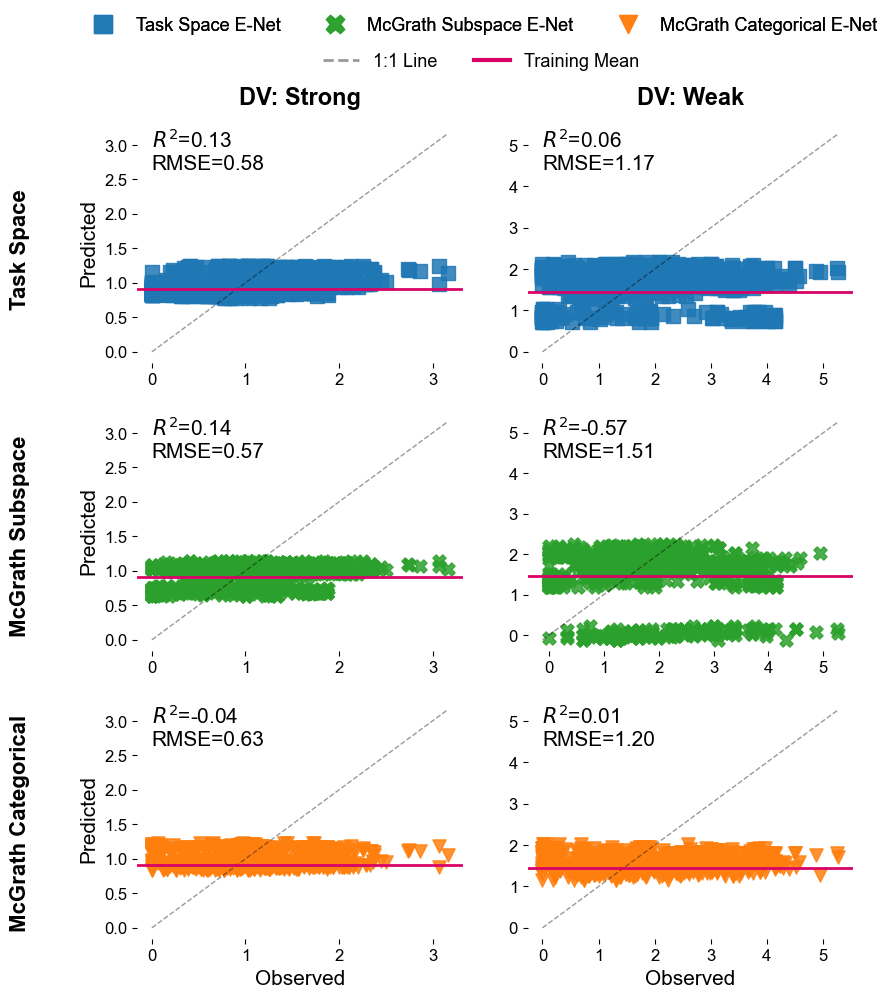

In [34]:
plot_group_advantage_pred_vs_obs_strong_weak(
    MODELS, wave, TRAIN_TEST_DATA, custom_r2, ["Task Space", "McGrath Subspace", "McGrath Categorical"],
    get_rmse_ols, get_rmse_for_enet,
    models_to_plot=["E-Net"]
)

In [40]:
def add_interactions(X):
	poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
	return poly.fit_transform(X)

In [52]:
def plot_group_advantage_rmse_with_r2(
    MODELS, wave, DATA, custom_r2, ivs_selected,
    get_rmse_ols, get_rmse_for_enet,
    models_to_plot=None
):
    fallback_color = "#888"
    dvs = ["strong", "weak"]
    if models_to_plot is None:
        models = ["OLS", "E-Net"]
    else:
        models = [m for m in models_to_plot if m in ["OLS", "E-Net", "NN"]]

    results = []
    for iv in ivs_selected:
        if iv == "Task Space": ivs = basic_IVs
        elif iv == "McGrath Categorical": ivs = categorical_IVs
        elif iv == "McGrath Subspace": ivs = mcgrath_continuous
        else: raise ValueError(f"Unknown IV type: {iv}")

        for model in models:
            for dv in dvs:
                try:
                    mdl = MODELS[iv][model][wave][dv]
                except:
                    continue
                Xtest_all = DATA[wave]["test"]
                y = Xtest_all[dv].values
                ytr = DATA[wave]["train"][dv].mean()

                # --- Prediction logic ---
                if model == "OLS":
                    X = sm.add_constant(Xtest_all[ivs], has_constant="add")
                    yhat = mdl.predict(X)

                elif model == "E-Net":
                    # new path: call predict_enet directly
                    try:
                        yhat = predict_enet(mdl, Xtest_all)
                    except Exception:
                        continue

                elif model == "NN":
                    X = Xtest_all[ivs]
                    yhat = mdl(X)
                    if hasattr(yhat, "detach"):
                        yhat = yhat.detach().numpy()
                    if hasattr(yhat, "flatten"):
                        yhat = yhat.flatten()
                else:
                    continue

                # --- Metrics ---
                if model == "OLS":
                    rmse = get_rmse_ols(mdl, Xtest_all, y, ivs)
                elif model == "E-Net":
                    rmse = get_rmse_for_enet(mdl, Xtest_all, y, ivs)
                else:
                    rmse = np.sqrt(np.mean((yhat - y) ** 2))

                r2 = custom_r2(yhat, y, DATA[wave]["train"], DATA[wave]["test"], dv)
                baseline_rmse = np.sqrt(np.mean((ytr - y) ** 2))

                # bootstrap CI
                residuals = yhat - y
                boot_rmse = [
                    np.sqrt(np.mean(np.random.choice(residuals, size=len(residuals), replace=True) ** 2))
                    for _ in range(1000)
                ]
                ci_low, ci_high = np.percentile(boot_rmse, [2.5, 97.5])

                results.append({
                    "iv": iv, "dv": dv, "model": model,
                    "rmse": rmse, "r2": r2,
                    "ci_low": ci_low, "ci_high": ci_high,
                    "baseline": baseline_rmse
                })

    df_res = pd.DataFrame(results)

    n_models = len(models)
    fig, axes = plt.subplots(n_models, len(dvs), figsize=(9.3, 4.5 * n_models), squeeze=False)
    if n_models == 1:
        axes = axes[0]

    for row, model in enumerate(models):
        for col, dv in enumerate(dvs):
            ax = axes[row, col] if n_models > 1 else axes[col]
            sub = df_res[(df_res["dv"] == dv) & (df_res["model"] == model)]
            if sub.empty:
                ax.axis("off")
                continue

            colors = [base_palette.get(iv, fallback_color) for iv in sub["iv"]]
            yerr = [sub["rmse"] - sub["ci_low"], sub["ci_high"] - sub["rmse"]]

            bars = ax.bar(
                range(len(sub)), sub["rmse"], color=colors,
                edgecolor="black", alpha=0.85, yerr=yerr
            )

            for bar, (r2, rmse) in zip(bars, zip(sub["r2"], sub["rmse"])):
                height = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width()/2, height*0.6,
                    f"$R^2$={r2:.2f}", ha="center", va="center",
                    fontsize=13, color="white"
                )
                ax.text(
                    bar.get_x() + bar.get_width()/2, height*0.5,
                    f"RMSE={rmse:.2f}", ha="center", va="center",
                    fontsize=10, color="white"
                )

            baseline = sub["baseline"].iloc[0]
            ax.axhline(baseline, color="#D90368", lw=2)

            ax.set_title(
                "Strong Group Advantage" if dv == "strong" else "Weak Group Advantage",
                fontsize=16, fontweight="bold"
            )
            ax.set_ylabel("RMSE", fontsize=14)
            ax.tick_params(axis="x", labelsize=12)
            ax.tick_params(axis="y", labelsize=12)
            ax.set_xticks([])
            [sp.set_visible(False) for sp in ax.spines.values()]
            ax.set_facecolor("white")

        if n_models > 1:
            fig.text(
                -0.02, (axes[row,0].get_position().y0 + axes[row,0].get_position().y1)/2 + 0.02,
                f"Model Type: {model}", ha="center", va="center", rotation=90,
                fontsize=16, fontweight="bold"
            )

    handles = [plt.Rectangle((0,0),1,1, color=base_palette.get(iv, fallback_color))
               for iv in ivs_selected]
    labels = ivs_selected
    handles.append(Line2D([0], [0], color="#D90368", lw=2))
    labels.append("Training Mean RMSE")

    fig.legend(handles, labels, loc="lower center", ncol=len(labels), fontsize=12, frameon=False)

    plt.tight_layout(rect=[0,0.08,1,1])
    plt.savefig(f"../outputs/group_advantage_observation_level_rmse_{wave}_{'_'.join(ivs_selected)}_{'_'.join(models)}.png",
                bbox_inches="tight")
    plt.savefig(f"../outputs/group_advantage_observation_level_rmse_{wave}_{'_'.join(ivs_selected)}_{'_'.join(models)}.pdf",
                bbox_inches="tight")
    plt.show()

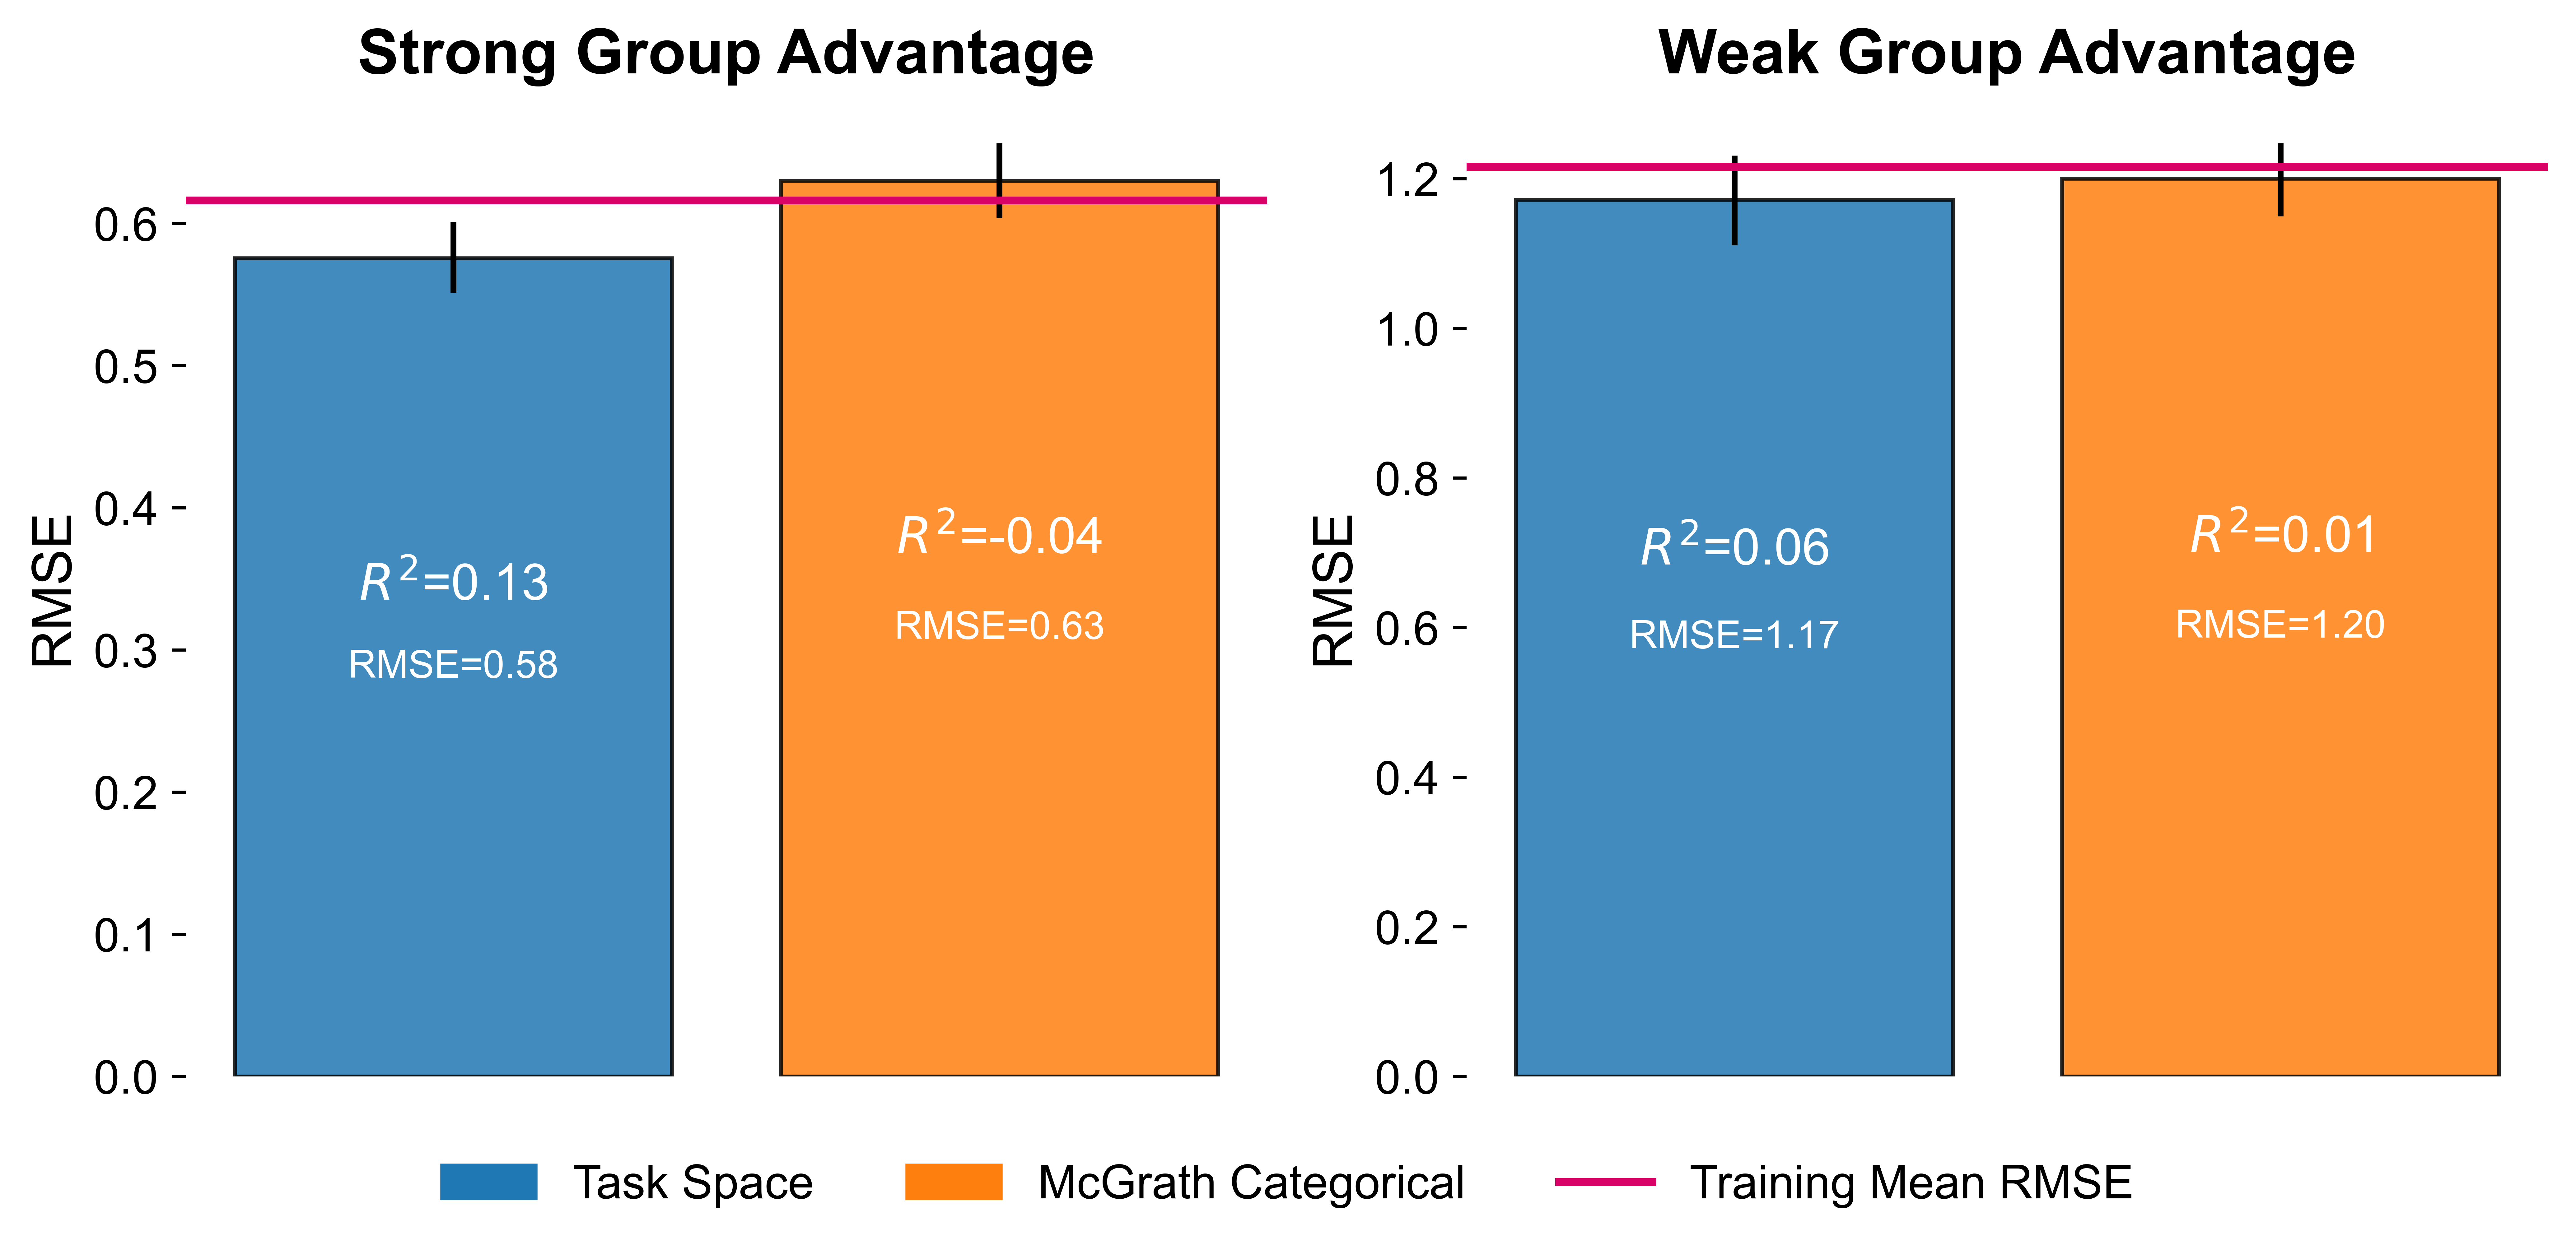

In [53]:
# versions without McGrath Subspace for slide show
plot_group_advantage_rmse_with_r2(
	MODELS, "Wave 2", TRAIN_TEST_DATA, custom_r2,
	["Task Space", "McGrath Categorical"],
	get_rmse_ols, get_rmse_for_enet,
	models_to_plot= ["E-Net"] 
)